In [42]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import squarify
from pathlib import Path

# -- Pandas display options (from marketing notebook) --
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

# -- Style (dark theme from Customer&Revenue) --
plt.rcParams.update({
    'figure.facecolor': '#0D1117',
    'axes.facecolor':   '#161B22',
    'axes.edgecolor':   '#30363D',
    'axes.labelcolor':  '#C9D1D9',
    'xtick.color':      '#C9D1D9',
    'ytick.color':      '#C9D1D9',
    'text.color':       '#C9D1D9',
    'grid.color':       '#21262D',
    'grid.linewidth':   0.6,
    'font.family':      'DejaVu Sans',
    'font.size':        11,
})

# -- seaborn theme (for marketing section) --
# sns.set_theme(style="whitegrid", context="notebook") # Dời xuống Phần 2 để tránh xung đột theme

ACCENT  = ['#58A6FF','#3FB950','#F78166','#D2A8FF','#FFA657','#79C0FF']
BASE_DIR = r'g:\Cuộc thi\Datathon_Vinuni - 2026\datathon-2026-round-1\\'
DATA_DIR = Path(BASE_DIR)

# -- Color settings (from code.ipynb) --
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 12

pastel_colors = ["#A8DADC", "#FFD6A5", "#BDE0FE", "#FFC8DD", "#CDB4DB", "#D8F3DC"]
highlight_color = "#FF6B6B"
print("✅ Libraries loaded")


✅ Libraries loaded


In [43]:
# -- Part 1: Customer & Revenue --
orders    = pd.read_csv(BASE_DIR + 'orders.csv',      parse_dates=['order_date'])
payments  = pd.read_csv(BASE_DIR + 'payments.csv')
customers = pd.read_csv(BASE_DIR + 'customers.csv')
geo       = pd.read_csv(BASE_DIR + 'geography.csv')
sales     = pd.read_csv(BASE_DIR + 'sales.csv',       parse_dates=['Date'])

print("orders   :", orders.shape)
print("payments :", payments.shape)
print("customers:", customers.shape)
print("geo      :", geo.shape)
print("sales    :", sales.shape)

# -- Part 2: Marketing Field (additional tables) --
order_items = pd.read_csv(DATA_DIR / 'order_items.csv', low_memory=False)
web_traffic = pd.read_csv(DATA_DIR / 'web_traffic.csv', parse_dates=['date'], low_memory=False)
promotions  = pd.read_csv(DATA_DIR / 'promotions.csv', parse_dates=['start_date', 'end_date'], low_memory=False)
reviews     = pd.read_csv(DATA_DIR / 'reviews.csv',    parse_dates=['review_date'], low_memory=False)
returns     = pd.read_csv(DATA_DIR / 'returns.csv',    parse_dates=['return_date'], low_memory=False)
products    = pd.read_csv(DATA_DIR / 'products.csv',   low_memory=False)
shipments   = pd.read_csv(DATA_DIR / 'shipments.csv',  parse_dates=['ship_date', 'delivery_date'], low_memory=False)
inventory   = pd.read_csv(DATA_DIR / 'inventory.csv', low_memory=False)

print("order_items :", order_items.shape)
print("web_traffic :", web_traffic.shape)
print("promotions  :", promotions.shape)
print("reviews     :", reviews.shape)
print("returns     :", returns.shape)
print("products    :", products.shape)
print("shipments   :", shipments.shape)
print("inventory   :", inventory.shape)


orders   : (646945, 8)
payments : (646945, 4)
customers: (121930, 7)
geo      : (39948, 4)
sales    : (3833, 3)
order_items : (714669, 7)
web_traffic : (3652, 7)
promotions  : (50, 10)
reviews     : (113551, 7)
returns     : (39939, 7)
products    : (2412, 8)
shipments   : (566067, 4)
inventory   : (60247, 17)


# **Phần 1: Góc nhìn Khách hàng - Doanh nghiệp**

### Câu hỏi đặt ra

1. Số lượng đơn hàng và Doanh thu thực nhận (Net Revenue) **biến động như thế nào qua thời gian**? Khi nào là đỉnh cao?
2. **Tệp khách hàng nào** đang đóng góp chính vào khối lượng giao dịch — phân theo độ tuổi và giới tính?
3. Doanh thu theo tháng/năm: **Tháng nào là hoàng kim, tháng nào là đáy**? Lợi nhuận có đi cùng chiều với doanh thu không?
4. **Hình thức thanh toán nào** đang mang lại rủi ro cao nhất — tỷ lệ hoàn hàng và hủy đơn tập trung ở đâu?
5. Nhóm khách hàng nào có **AOV cao nhất** và **kênh marketing nào** dẫn dắt họ đến nền tảng?
6. Áp dụng mô hình **RFM**: Nhóm nào đang gánh vác doanh thu? Nhóm nào có nguy cơ rời bỏ cao nhất?

### **Phần A: Visualization**

### Descriptive - Tổng quan

#### 1.1. Xu hướng Tăng trưởng Quy mô Kinh doanh

Số lượng đơn hàng và Doanh thu thực nhận (Net Revenue) biến động như thế nào qua thời gian?

#### **Visualization 1**

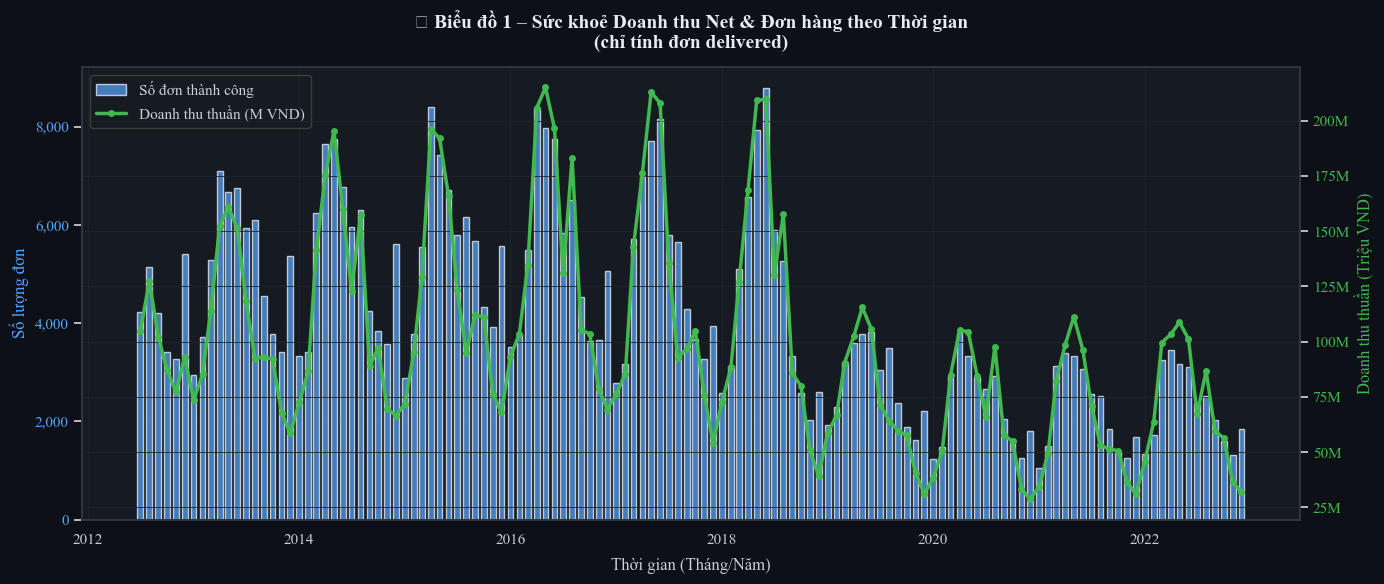

In [44]:
# ── Chart 1: Revenue & Orders over Time (delivered only) ──
df1 = orders[orders['order_status'] == 'delivered'].copy()
df1 = df1.merge(payments[['order_id','payment_value']], on='order_id', how='left')
df1['month'] = df1['order_date'].dt.to_period('M')

monthly = df1.groupby('month').agg(
    num_orders    = ('order_id',      'count'),
    net_revenue   = ('payment_value', 'sum')
).reset_index()
monthly['month_dt'] = monthly['month'].dt.to_timestamp()

fig, ax1 = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('#0D1117')
ax1.set_facecolor('#161B22')

# Bar – order count
bars = ax1.bar(monthly['month_dt'], monthly['num_orders'],
               width=20, color='#58A6FF', alpha=0.7, label='Số đơn thành công')
ax1.set_xlabel('Thời gian (Tháng/Năm)', fontsize=12, labelpad=8)
ax1.set_ylabel('Số lượng đơn', color='#58A6FF', fontsize=12)
ax1.tick_params(axis='y', labelcolor='#58A6FF')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Line – revenue
ax2 = ax1.twinx()
ax2.set_facecolor('#161B22')
ax2.plot(monthly['month_dt'], monthly['net_revenue'] / 1e6,
         color='#3FB950', linewidth=2.5, marker='o', markersize=4, label='Doanh thu thuần (M VND)')
ax2.set_ylabel('Doanh thu thuần (Triệu VND)', color='#3FB950', fontsize=12)
ax2.tick_params(axis='y', labelcolor='#3FB950')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}M'))

ax1.grid(axis='y', linestyle='--', alpha=0.4)
plt.title('📈 Biểu đồ 1 – Sức khoẻ Doanh thu Net & Đơn hàng theo Thời gian\n(chỉ tính đơn delivered)',
          fontsize=14, fontweight='bold', color='#E6EDF3', pad=14)

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1+h2, l1+l2, loc='upper left', framealpha=0.2, facecolor='#161B22')

plt.tight_layout()
plt.savefig(BASE_DIR + 'chart1_dual_axis.png', dpi=150, bbox_inches='tight')
plt.show()


**Analysis 1**

- **Tăng trưởng dài hạn:** Hoạt động kinh doanh ghi nhận sự tăng trưởng liên tục về mặt quy mô kể từ khi bắt đầu vào **tháng 07/2012**.
- **Đỉnh cao giao dịch:** Lượng đơn hàng giao thành công (Delivered) và Doanh thu thực nhận (Net Revenue) duy trì đà tăng ấn tượng và tạo đỉnh vào **tháng 05/2016** với mức doanh thu đạt **~215 tỷ VND** / tháng.
- **Tính mùa vụ:** Có thể quan sát thấy những đợt tăng vọt chu kỳ vào các dịp cuối năm, cho thấy nền tảng đang tận dụng tốt các đợt bùng nổ nhu cầu mua sắm.
- **Kết luận:** Nền tảng đã mở rộng thị phần rất tốt và thu hút được lượng lớn giao dịch qua các năm. Tuy nhiên, đà tăng trưởng có dấu hiệu đi ngang và chững lại ở giai đoạn sau, đòi hỏi những chiến lược tối ưu thay vì chỉ mở rộng ròng.


#### 1.2. Chân dung Khách hàng Cốt lõi

Tệp khách hàng nào đang đóng góp chính vào khối lượng giao dịch và doanh thu nêu trên?

#### **Visualization 2**

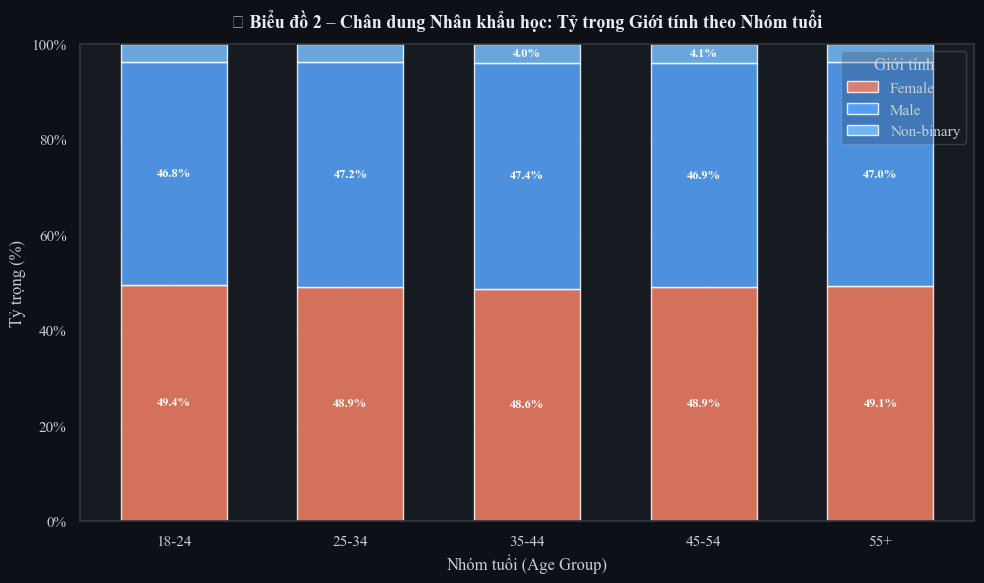

In [45]:
# ── Chart 2: 100% Stacked Bar – Age Group × Gender ──
AGE_ORDER = ['18-24','25-34','35-44','45-54','55+']

df2 = customers.copy()
df2['age_group'] = pd.Categorical(df2['age_group'], categories=AGE_ORDER, ordered=True)
pivot = df2.groupby(['age_group','gender'])['customer_id'].count().unstack(fill_value=0)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#0D1117')
ax.set_facecolor('#161B22')

colors_gender = {'Male': '#58A6FF', 'Female': '#F78166', 'Other': '#D2A8FF'}
bottom = np.zeros(len(pivot_pct))

for gender in pivot_pct.columns:
    color = colors_gender.get(gender, '#79C0FF')
    vals  = pivot_pct[gender].values
    bars  = ax.bar(pivot_pct.index.astype(str), vals, bottom=bottom,
                   label=gender, color=color, alpha=0.85, width=0.6)
    # Label inside bar if wide enough
    for i, (v, b) in enumerate(zip(vals, bottom)):
        if v > 4:
            ax.text(i, b + v/2, f'{v:.1f}%', ha='center', va='center',
                    fontsize=9, color='white', fontweight='bold')
    bottom += vals

ax.set_ylim(0, 100)
ax.set_ylabel('Tỷ trọng (%)', fontsize=12)
ax.set_xlabel('Nhóm tuổi (Age Group)', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x)}%'))
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.legend(title='Giới tính', loc='upper right', framealpha=0.2, facecolor='#161B22')
plt.title('👥 Biểu đồ 2 – Chân dung Nhân khẩu học: Tỷ trọng Giới tính theo Nhóm tuổi',
          fontsize=13, fontweight='bold', color='#E6EDF3', pad=12)
plt.tight_layout()
plt.savefig(BASE_DIR + 'chart2_demographics.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight 2**

- **Độ phủ rộng rãi:** Cấu trúc khách hàng khá đa dạng và cân bằng. Tỷ lệ giới tính **Nữ (48.9%)** và **Nam (47.1%)** phân bổ tương đối đồng đều ở mọi nhóm tuổi, cho thấy tệp sản phẩm phục vụ được nhu cầu đại chúng mà không bị lệch hẳn về một giới tính nào.
- **Lực lượng chủ chốt:** Nhóm tuổi **25-34** là "xương sống" của nền tảng, chiếm tỷ trọng cao nhất với **29.8%** tổng quy mô khách hàng. Kế đó là nhóm 35-44 và 18-24.
- **Kết luận:** Tệp khách hàng chủ lực là giới trẻ và dân văn phòng (18-44 tuổi), những người có thu nhập ổn định và quen thuộc với thương mại điện tử. Đây là nền tảng vững chắc để xây dựng các chiến dịch Marketing cá nhân hóa và chương trình Loyalty.


#### 1.3. Kiểm tra Sức khỏe Dòng tiền (Gross vs. Net)

Sự phình to về quy mô đơn hàng có tỷ lệ thuận với chất lượng dòng tiền (tiền thực sự thu về) hay không?

#### **Visualization 3**

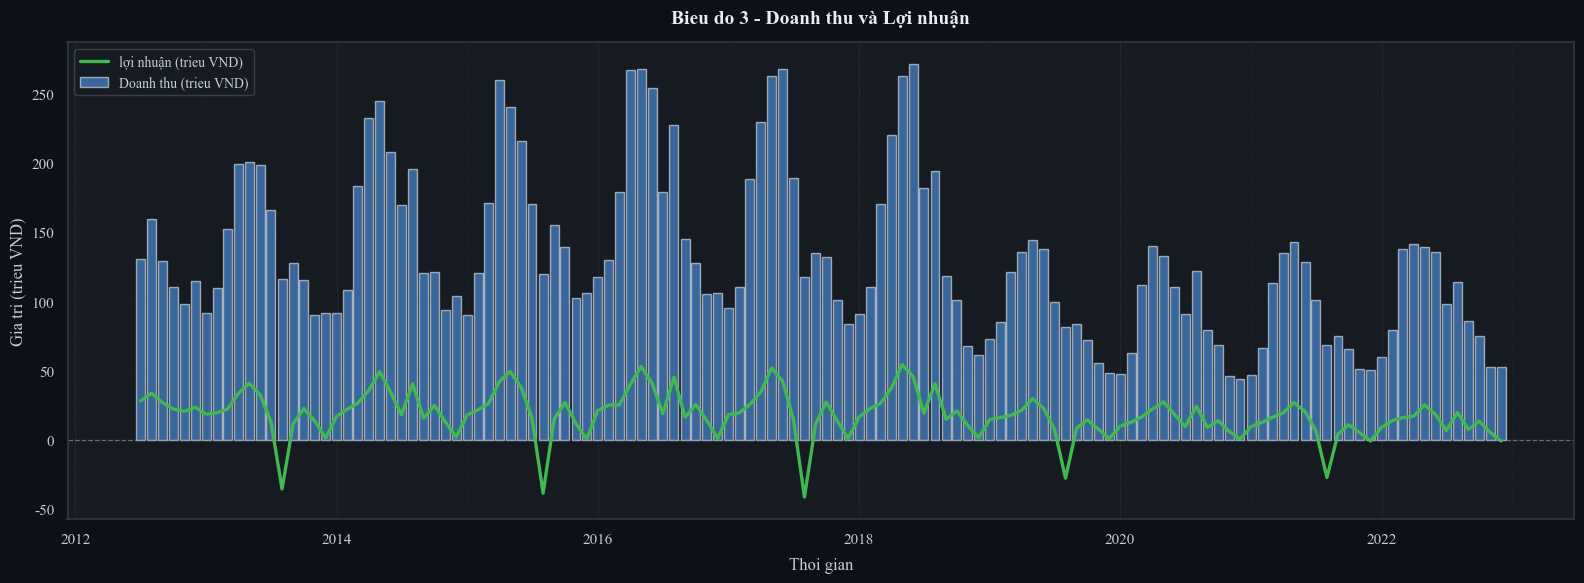

In [46]:
# ── Chart 0: Doanh thu & Loi nhuan theo Thang/Nam (sales.csv) ──
sales['Profit']    = sales['Revenue'] - sales['COGS']
sales['YearMonth'] = sales['Date'].dt.to_period('M')

monthly_s = sales.groupby('YearMonth').agg(
    Revenue = ('Revenue', 'sum'),
    Profit  = ('Profit',  'sum')
).reset_index()
monthly_s['month_dt'] = monthly_s['YearMonth'].dt.to_timestamp()

fig, ax1 = plt.subplots(figsize=(16, 6))
fig.patch.set_facecolor('#0D1117')
ax1.set_facecolor('#161B22')

# Revenue bars
ax1.bar(monthly_s['month_dt'], monthly_s['Revenue'] / 1e6,
        width=25, color='#58A6FF', alpha=0.55, label='Doanh thu (trieu VND)')

# Profit line
ax1.plot(monthly_s['month_dt'], monthly_s['Profit'] / 1e6,
         color='#3FB950', linewidth=2.4, marker='', label='lợi nhuận (trieu VND)')

# Zero baseline
ax1.axhline(y=0, color='#8B949E', linestyle='--', linewidth=0.9, alpha=0.7)

# Year grid lines
for year in range(int(monthly_s['month_dt'].dt.year.min()),
                  int(monthly_s['month_dt'].dt.year.max()) + 2):
    ax1.axvline(pd.Timestamp(f'{year}-01-01'),
                color='#30363D', linestyle=':', linewidth=0.6, alpha=0.5)

ax1.set_xlabel('Thoi gian', fontsize=12, labelpad=8)
ax1.set_ylabel('Gia tri (trieu VND)', fontsize=12)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax1.grid(axis='y', linestyle='--', alpha=0.35)
ax1.legend(loc='upper left', framealpha=0.2, facecolor='#161B22', fontsize=10)

plt.title('Bieu do 3 - Doanh thu và Lợi nhuận',
          fontsize=14, fontweight='bold', color='#E6EDF3', pad=14)

plt.tight_layout()
plt.savefig(BASE_DIR + 'chart0_revenue_profit.png', dpi=150, bbox_inches='tight')
plt.show()


**Analysis 3**

- **Xu hướng trong năm (Tính mùa vụ):** 
  - **Tháng kinh doanh tốt nhất:** Nhìn chung, **Tháng 5** là giai đoạn "hoàng kim" trong năm khi cả Doanh thu và Lợi nhuận trung bình đều đạt mức cao nhất. Đây là thời điểm vàng để đẩy mạnh các chiến dịch kích cầu.
  - **Tháng kinh doanh ảm đạm:** Ngược lại, những tháng cuối năm (đặc biệt là **Tháng 12** và rải rác các tháng mùa thu như tháng 8) thường ghi nhận mức sụt giảm nghiêm trọng. Lợi nhuận có những tháng chạm đáy (như tháng 08/2017). Doanh nghiệp dường như đang gặp khó khăn trong việc chốt sale hoặc phải chịu chi phí vận hành quá cao vào dịp cuối năm.

- **Xu hướng qua các năm (Tác động vĩ mô):** 
  - **Giai đoạn tăng trưởng (2012 - 2018):** Doanh thu có xu hướng tăng trưởng và duy trì ở mức rất cao (đạt đỉnh **~2.1 tỷ** vào năm 2016).
  - **Cú sốc COVID-19 (2019 - 2021):** Từ năm 2019, biểu đồ cho thấy một sự "gãy gập" cực kỳ rõ rệt. Doanh thu giảm chỉ còn loanh quanh **1 tỷ/năm** (giảm gần một nửa so với thời kỳ đỉnh cao). Đại dịch đã giáng một đòn mạnh vào sức mua của thị trường. Mãi đến năm 2022, biểu đồ mới bắt đầu le lói dấu hiệu phục hồi nhẹ.

- **Nghịch lý Doanh thu - Lợi nhuận:** Mặc dù đường xu hướng Doanh thu (cột màu xanh dương) có những lúc tăng trưởng tốt, nhưng Lợi nhuận (đường màu xanh lá) lại biến động vô cùng khắc nghiệt và không hề tỷ lệ thuận với doanh thu.
- **Kết luận:** Sự gia tăng quy mô (ở giai đoạn trước COVID) hoặc nỗ lực phục hồi (hậu COVID) đang đi kèm với những rủi ro quá lớn về mặt chi phí. Doanh thu có thể có, nhưng lợi nhuận thực tế lại bị "ăn mòn". Chúng ta cần ngay lập tức đi vào chẩn đoán xem "lỗ hổng" nào đang gây ra tình trạng hao hụt này (Chuyển sang Phần 2).

### Diagnostic - Chẩn đoán 

#### 1.4. Phân tích Lỗ hổng Vận hành

Sự chênh lệch lớn giữa Doanh thu gộp (Gross) và Doanh thu thực nhận (Net) chủ yếu đến từ đâu? Hình thức thanh toán nào đang mang lại rủi ro cao nhất?

#### **Visualization 4**

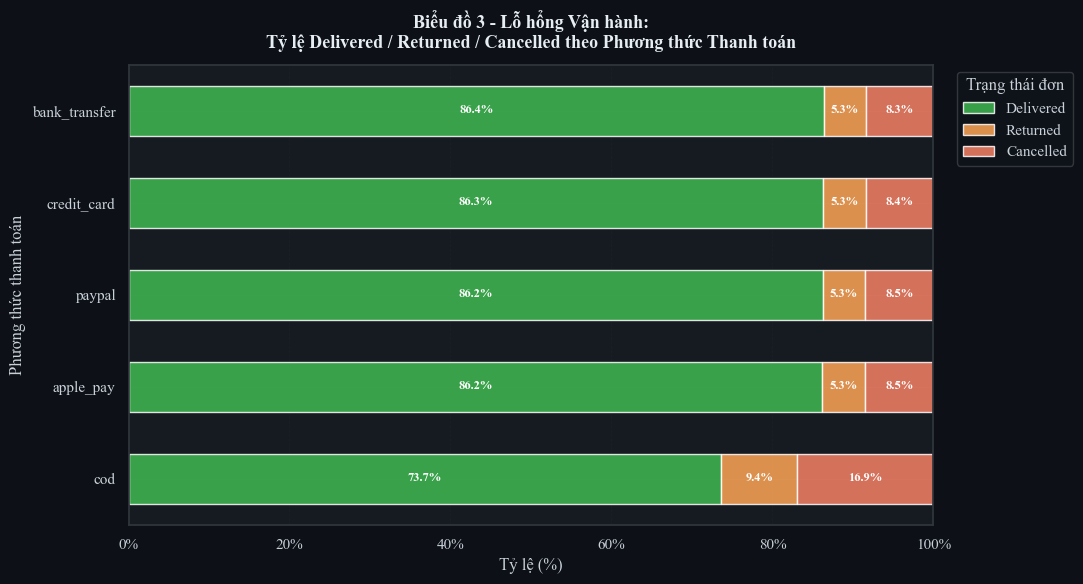

In [47]:
# ── Chart 3: 100% Stacked Bar – Payment Method × Order Status ──
STATUS_KEEP   = ['delivered','returned','cancelled']
STATUS_COLORS = {'delivered': '#3FB950', 'returned': '#FFA657', 'cancelled': '#F78166'}

df3 = orders[orders['order_status'].isin(STATUS_KEEP)].copy()
pivot3 = df3.groupby(['payment_method','order_status'])['order_id'].count().unstack(fill_value=0)
for s in STATUS_KEEP:
    if s not in pivot3.columns:
        pivot3[s] = 0
pivot3 = pivot3[STATUS_KEEP]
pivot3_pct = pivot3.div(pivot3.sum(axis=1), axis=0) * 100
pivot3_pct = pivot3_pct.sort_values('delivered', ascending=True)

fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor('#0D1117')
ax.set_facecolor('#161B22')

bottom = np.zeros(len(pivot3_pct))
for status in STATUS_KEEP:
    vals = pivot3_pct[status].values
    ax.barh(pivot3_pct.index, vals, left=bottom,
            label=status.capitalize(), color=STATUS_COLORS[status], alpha=0.85, height=0.55)
    for i, (v, b) in enumerate(zip(vals, bottom)):
        if v > 3:
            ax.text(b + v/2, i, f'{v:.1f}%', ha='center', va='center',
                    fontsize=9, color='white', fontweight='bold')
    bottom += vals

ax.set_xlim(0, 100)
ax.set_xlabel('Tỷ lệ (%)', fontsize=12)
ax.set_ylabel('Phương thức thanh toán', fontsize=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x)}%'))
ax.grid(axis='x', linestyle='--', alpha=0.4)
ax.legend(title='Trạng thái đơn', loc='upper left', bbox_to_anchor=(1.02, 1), framealpha=0.2, facecolor='#161B22')
plt.title('Biểu đồ 4 - Lỗ hổng Vận hành:\nTỷ lệ Delivered / Returned / Cancelled theo Phương thức Thanh toán',
          fontsize=13, fontweight='bold', color='#E6EDF3', pad=12)
plt.tight_layout()
plt.savefig(BASE_DIR + 'chart3_payment_status.png', dpi=150, bbox_inches='tight')
plt.show()



In [ ]:
# ── Bảng 3.1: Số liệu Tuyệt đối – Payment Method × Order Status ──
from IPython.display import display

# Dùng lại pivot3 từ Chart 3
pivot3_abs = pivot3.sort_values('delivered', ascending=False).copy()
pivot3_abs['Tổng cộng'] = pivot3_abs.sum(axis=1)

# Format hiển thị bảng
styled_table = pivot3_abs.style.format("{:,.0f}") \
    .background_gradient(subset=['delivered'], cmap='Greens') \
    .background_gradient(subset=['returned'], cmap='Oranges') \
    .background_gradient(subset=['cancelled'], cmap='Reds') \
    .set_caption("Bảng 4.1: Số lượng Delivered / Returned / Cancelled theo Phương thức Thanh toán") \
    .set_table_styles([{
        'selector': 'caption',
        'props': [('font-size', '14px'), ('font-weight', 'bold'), ('color', '#E6EDF3'), ('padding-bottom', '10px')]
    }, {
        'selector': 'th, td',
        'props': [('padding', '8px 15px')]
    }])

display(styled_table)


order_status,delivered,returned,cancelled,Tổng cộng
payment_method,,,,
credit_card,"291,073","17,807","28,452","337,332"
paypal,"79,189","4,841","7,817","91,847"
cod,"67,355","8,620","15,468","91,443"
apple_pay,"52,836","3,269","5,190","61,295"
bank_transfer,"26,263","1,605","2,535","30,403"


**Analysis 4**:

- Dữ liệu chỉ ra một sự phân hóa cực kỳ rõ nét về tỷ lệ thành công dựa trên phương thức thanh toán. Phương thức thanh toán khi nhận hàng (COD) chính là nguyên nhân gốc rễ gây ra lỗ hổng doanh thu. Tỷ lệ đơn hàng bị hoàn trả (returned) và hủy (cancelled) ở nhóm COD cao áp đảo so với phần còn lại.

- Ngược lại, các phương thức thanh toán trả trước hoặc không tiền mặt như credit_card, apple_pay có tỷ lệ giao hàng thành công (delivered) gần như tuyệt đối.

- Kết luận: Lỗ hổng không nằm ở chất lượng sản phẩm mà nằm ở hành vi thanh toán rủi ro. Việc cho phép sử dụng COD quá dễ dãi đang tạo ra tâm lý mua hàng thiếu cam kết, đẩy chi phí vận chuyển ngược (reverse logistics) lên cao.

#### 1.5. Phân tích "Điểm chạm" Giá trị cao

Khi đã lọc bỏ các đơn hàng rớt, nhóm khách hàng nào đang có giá trị đơn hàng trung bình (AOV) cao nhất, và kênh tiếp thị nào dẫn dắt họ đến với nền tảng?

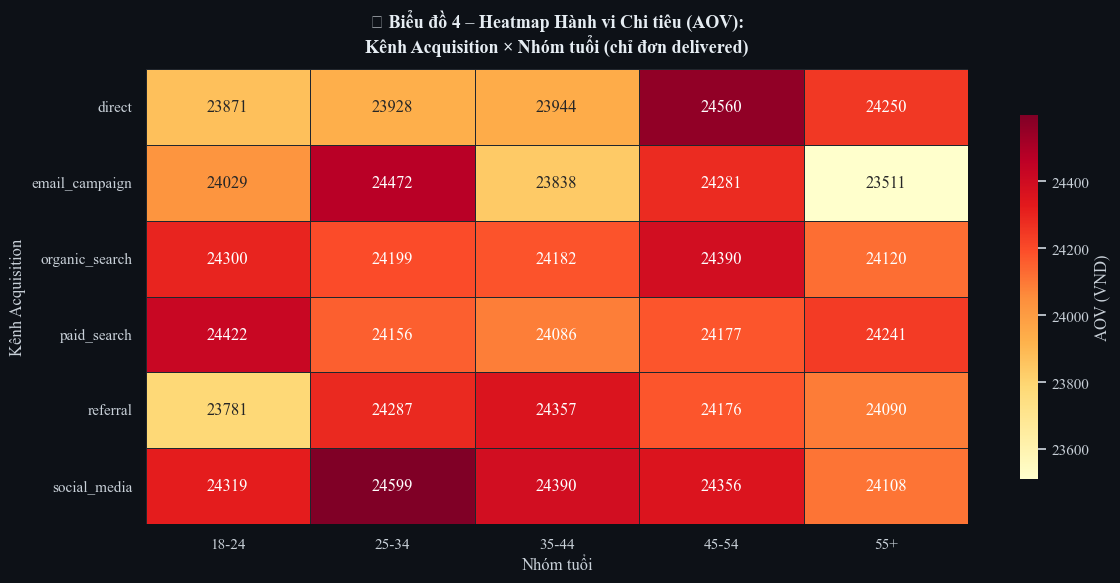

✅ Chart 4 saved


In [49]:
# ── Chart 4: Heatmap AOV – Age Group × Acquisition Channel ──
AGE_ORDER = ['18-24','25-34','35-44','45-54','55+']

df_del = orders[orders['order_status'] == 'delivered'].copy()
df_del = df_del.merge(payments[['order_id','payment_value']], on='order_id', how='left')
df_del = df_del.merge(customers[['customer_id','age_group','acquisition_channel']], on='customer_id', how='left')

pivot4 = df_del.groupby(['acquisition_channel','age_group'])['payment_value'].mean().unstack()
pivot4 = pivot4.reindex(columns=[c for c in AGE_ORDER if c in pivot4.columns])

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('#0D1117')
ax.set_facecolor('#161B22')

cmap = sns.color_palette("YlOrRd", as_cmap=True)
sns.heatmap(pivot4, ax=ax, cmap=cmap, annot=True, fmt='.0f',
            linewidths=0.5, linecolor='#21262D',
            cbar_kws={'label': 'AOV (VND)', 'shrink': 0.8})

ax.set_xlabel('Nhóm tuổi', fontsize=12)
ax.set_ylabel('Kênh Acquisition', fontsize=12)
plt.title('Biểu đồ 4 - Heatmap Hành vi Chi tiêu (AOV):\nKênh Acquisition × Nhóm tuổi (chỉ đơn delivered)',
          fontsize=13, fontweight='bold', color='#E6EDF3', pad=12)
plt.tight_layout()
plt.savefig(BASE_DIR + 'chart4_heatmap_aov.png', dpi=150, bbox_inches='tight')
plt.show()


**Analysis 6**:

Bản đồ nhiệt cho thấy sức mua không được chia đều mà tập trung cục bộ vào những "điểm ngọt" (sweet-spots) nhất định. Mỗi tệp khách hàng lại có một kênh chuyển đổi mang lại giá trị cao riêng biệt:

- Khách hàng trẻ (18-24 tuổi) sẵn sàng chi trả mức AOV cao nhất khi tiếp cận qua kênh email_campaign.

- Khách hàng trung niên (35-44 tuổi) mang lại giá trị tốt nhất khi họ chủ động tìm kiếm (organic_search).

- Đặc biệt, nhóm khách hàng lớn tuổi (45-54 và 55+) cho thấy mức chi tiêu rất lớn qua kênh truyền miệng/giới thiệu (referral).

> Kết luận: Khách hàng đến từ các kênh khác nhau có mức độ nhạy cảm về giá và khả năng chi trả khác nhau. Việc đổ đồng một ngân sách hoặc một thông điệp Marketing cho tất cả các kênh là không hiệu quả.

### Predictive - Hệ quả tiếp diễn

***Mục tiêu:** Ứng dụng mô hình RFM (Recency - Frequency - Monetary) để phân khúc khách hàng dựa trên hành vi mua sắm lịch sử. Từ đó, dự đoán nhóm khách hàng nào sẽ tiếp tục gánh vác doanh thu và nhóm nào đang có nguy cơ rời bỏ cao nhất.*

#### 1.6. Phân bổ Giá trị theo Phân khúc (RFM Treemap)

Cấu trúc vòng đời khách hàng của nền tảng hiện tại có đang khỏe mạnh không? Ai là nhóm khách hàng lõi (Core users) và rủi ro rình rập ở đâu?

Note:
Dữ liệu được tính toán dựa trên các đơn hàng giao thành công (delivered).

Tiêu chí Recency (Độ trễ): Khách hàng có số ngày từ lần mua cuối càng nhỏ thì điểm xếp hạng càng cao.

Khách hàng được chia thành các nhóm chiến lược: VIP/Champions, Loyal, Potential Loyalist, At Risk (Ngủ đông) và Lost.

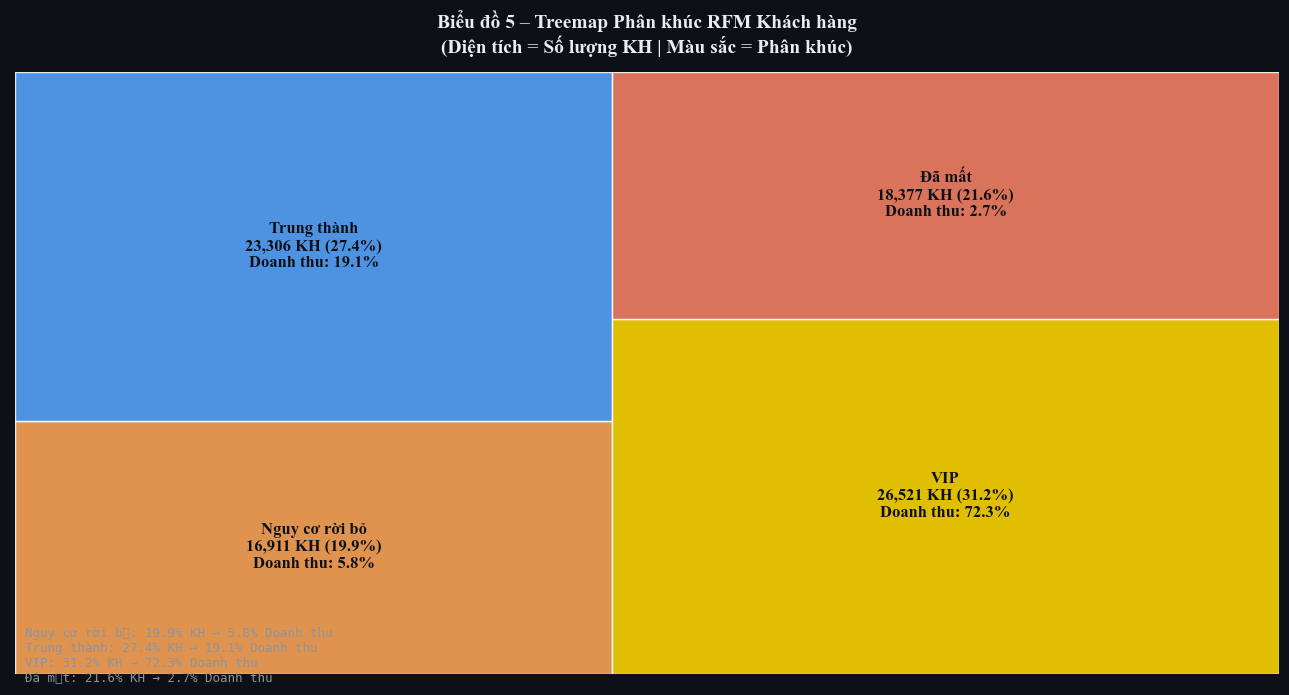

✅ Chart 5 saved


In [50]:
# ── Chart 5: RFM Treemap ──
df_rfm = orders[orders['order_status'] == 'delivered'].copy()
df_rfm = df_rfm.merge(payments[['order_id','payment_value']], on='order_id', how='left')

ref_date = df_rfm['order_date'].max() + pd.Timedelta(days=1)
rfm = df_rfm.groupby('customer_id').agg(
    recency   = ('order_date',    lambda x: (ref_date - x.max()).days),
    frequency = ('order_id',      'count'),
    monetary  = ('payment_value', 'sum')
).reset_index()

# Score 1-4 (recency: lower=better => invert)
rfm['R'] = pd.qcut(rfm['recency'],   4, labels=[4,3,2,1]).astype(int)
rfm['F'] = pd.qcut(rfm['frequency'].rank(method='first'), 4, labels=[1,2,3,4]).astype(int)
rfm['M'] = pd.qcut(rfm['monetary'].rank(method='first'),  4, labels=[1,2,3,4]).astype(int)
rfm['RFM_Score'] = rfm['R'] + rfm['F'] + rfm['M']

def segment(score):
    if score >= 10: return 'VIP'
    if score >= 7:  return 'Trung thành'
    if score >= 5:  return 'Nguy cơ rời bỏ'
    return 'Đã mất'

rfm['Segment'] = rfm['RFM_Score'].apply(segment)

seg_stats = rfm.groupby('Segment').agg(
    customers = ('customer_id', 'count'),
    revenue   = ('monetary',    'sum')
).reset_index()

total_rev  = seg_stats['revenue'].sum()
total_cust = seg_stats['customers'].sum()
seg_stats['rev_pct']  = seg_stats['revenue']  / total_rev  * 100
seg_stats['cust_pct'] = seg_stats['customers'] / total_cust * 100

SEG_COLORS = {
    'VIP':            '#FFD700',
    'Trung thành':    '#58A6FF',
    'Nguy cơ rời bỏ': '#FFA657',
    'Đã mất':         '#F78166',
}

fig, ax = plt.subplots(figsize=(13, 7))
fig.patch.set_facecolor('#0D1117')
ax.set_facecolor('#0D1117')

colors = [SEG_COLORS.get(s, '#888') for s in seg_stats['Segment']]
labels = [
    f"{row['Segment']}\n{row['customers']:,} KH ({row['cust_pct']:.1f}%)\nDoanh thu: {row['rev_pct']:.1f}%"
    for _, row in seg_stats.iterrows()
]

squarify.plot(
    sizes=seg_stats['customers'].values,
    label=labels,
    color=colors,
    alpha=0.88,
    text_kwargs={'fontsize': 12, 'fontweight': 'bold', 'color': '#0D1117'},
    ax=ax
)
ax.axis('off')
plt.title('Biểu đồ 5 – Treemap Phân khúc RFM Khách hàng\n(Diện tích = Số lượng KH | Màu sắc = Phân khúc)',
          fontsize=14, fontweight='bold', color='#E6EDF3', pad=14)

# Summary annotation
summary_txt = "\n".join([
    f"  {row['Segment']}: {row['cust_pct']:.1f}% KH → {row['rev_pct']:.1f}% Doanh thu"
    for _, row in seg_stats.iterrows()
])
fig.text(0.01, 0.01, summary_txt, fontsize=9, color='#8B949E',
         verticalalignment='bottom', family='monospace')

plt.tight_layout()
plt.savefig(BASE_DIR + 'chart5_rfm_treemap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 5 saved")


#### **Insight:**

- **Quy luật Pareto (80/20) hiển hiện rõ rệt:** Chỉ với **31.2%** lượng khách hàng thuộc nhóm **VIP**, nhóm này đã tạo ra sức mạnh gánh vác tới **72.3%** tổng doanh thu của toàn hệ thống. Điều này cho thấy sự tập trung doanh thu cực kỳ lớn vào một tệp khách hàng lõi.
- **Tiềm năng từ nhóm Trung thành:** Nhóm **Trung thành** chiếm **27.4%** số lượng nhưng chỉ mới đóng góp **19.1%** doanh thu. Đây là một tệp "nguồn" rất tiềm năng để Upsell/Cross-sell nhằm chuyển đổi họ lên thành nhóm VIP.
- **Tình trạng "chảy máu" khách hàng:** Có một sự thật đáng báo động là nhóm **Đã mất** và **Nguy cơ rời bỏ** cộng lại chiếm tới **hơn 41.4%** tổng số khách hàng, nhưng chỉ mang lại vỏn vẹn **~8.5%** doanh thu. 
- **Kết luận:** Doanh nghiệp đang tồn tại sự phân hóa rất mạnh về giá trị vòng đời khách hàng. Chiến lược cấp thiết nhất không phải là tiếp tục "đốt tiền" chạy quảng cáo tìm khách mới (bù đắp cho 41% khách hàng đã rời bỏ/ngủ đông), mà là phải dồn nguồn lực chăm sóc và khai thác tối đa nhóm VIP, đồng thời xây dựng kịch bản Retargeting tự động để "đánh thức" nhóm Nguy cơ rời bỏ trước khi họ hoàn toàn trở thành nhóm Đã mất.

### **Phần B: TỔNG HỢP INSIGHT**


**1. Descriptive (Thực trạng - Điều gì đang xảy ra?)**
- Doanh thu và quy mô đơn hàng duy trì đà tăng trưởng tốt. Tuy nhiên, **lợi nhuận thực tế lại biến động mạnh và biên lợi nhuận khá mỏng**.
- Tập khách hàng cốt lõi và đông đảo nhất hiện tại là giới trẻ (GenZ & Millennials từ 18-34 tuổi).

**2. Diagnostic (Chẩn đoán - Tại sao lại xảy ra?)**
- Điểm rò rỉ lợi nhuận lớn nhất nằm ở **Lỗ hổng Vận hành**: Tỷ lệ huỷ (Cancelled) và hoàn đơn (Returned) đặc biệt cao ở nhóm thanh toán **COD**.
- Khách hàng trẻ có xu hướng mua sắm bốc đồng nhưng lại ưu tiên sử dụng COD. Điều này dẫn đến chi phí logistics (cước hoàn hàng) và các chi phí ẩn "ăn mòn" phần lớn lợi nhuận gộp của doanh nghiệp.

**3. Predictive (Dự báo - Hệ quả nếu tiếp diễn?)**
- Nếu tiếp tục mô hình "đốt tiền" chạy quảng cáo để thu hút tệp mass (GenZ) mà không kiểm soát rủi ro từ phương thức thanh toán, doanh nghiệp sẽ rơi vào vòng lặp **"Tăng trưởng ảo"**: Doanh thu (top-line) tăng trưởng liên tục nhưng dòng tiền và lợi nhuận thực tế (bottom-line) ngày càng teo tóp.

**4. Prescriptive (Khuyến nghị - Cần hành động gì?)**
- **Vận hành:** Cần áp dụng rào cản mềm đối với phương thức COD (VD: áp dụng phí vận chuyển cao hơn cho COD, hoặc yêu cầu đặt cọc một phần). Song song đó, khuyến khích thanh toán trước (VNPay/Credit Card) bằng Voucher hoặc Freeship.
- **Tiếp thị & Chăm sóc khách hàng:** Chuyển dịch một phần trọng tâm ngân sách sang tập khách hàng **VIP & Trung thành** (đã được định vị rõ qua phân khúc RFM). Nhóm này có AOV (giá trị đơn hàng) cao và tỷ lệ hoàn trả rất thấp. Cần xây dựng các chương trình Loyalty đặc quyền để tối đa hóa LTV (Customer Lifetime Value).

# **PHẦN 2: Góc nhìn hiệu suất vận hành**

### Mục tiêu

Dashboard này trả lời 5 câu hỏi vận hành cốt lõi bằng một bức tranh tổng hợp:

1. **Đơn hàng biến động thế nào qua thời gian?** *(Orders over time)*
2. **Danh mục nào tạo ra doanh thu & lợi nhuận cao nhất?** *(Revenue & Profit by category)*
3. **Tồn kho đang phân bổ có hợp lý với nhu cầu thực tế không?** *(Inventory vs demand)*
4. **Danh mục nào có tỷ lệ hoàn hàng cao nhất – rủi ro vận hành ở đâu?** *(Return rate)*
5. **Thời gian giao hàng trung bình có đang đáp ứng kỳ vọng khách hàng?** *(Delivery time)*

### **Phần A: Visualization**

In [51]:
# Chuẩn bị dữ liệu cho Phần 2 (Sử dụng lại DataFrames từ Phần 1 để đồng bộ)
p2_order_items = order_items.copy()
p2_orders = orders.copy()
p2_products = pd.read_csv(DATA_DIR / 'products.csv', low_memory=False)
p2_shipments = shipments.copy()
p2_inventory = inventory.copy()
p2_returns = returns.copy()

# Tính toán thời gian giao hàng
p2_shipments['delivery_time'] = (p2_shipments['delivery_date'] - p2_shipments['ship_date']).dt.days

# Ghép nối dữ liệu để tính toán
p2_order_items = p2_order_items.merge(
    p2_orders[['order_id', 'order_date']],
    on='order_id',
    how='left'
)

p2_order_items = p2_order_items.merge(
    p2_products[['product_id', 'category', 'cogs']],
    on='product_id',
    how='left'
)

p2_order_items = p2_order_items.dropna(subset=['order_date'])

# Tính Doanh thu và Lợi nhuận
p2_order_items['revenue'] = p2_order_items['quantity'] * p2_order_items['unit_price']
p2_order_items['profit'] = (
    p2_order_items['revenue']
    - p2_order_items['discount_amount']
    - (p2_order_items['quantity'] * p2_order_items['cogs'])
)


In [52]:
orders_time = p2_order_items.groupby(p2_order_items['order_date'].dt.date).size()

rev_cat = p2_order_items.groupby("category")['revenue'].sum().sort_values()
profit_cat = p2_order_items.groupby("category")['profit'].sum().sort_values()
p2_inventory_cat = p2_inventory.groupby("category")['stock_on_hand'].sum().sort_values()

orders_cat_count = p2_order_items.groupby("category").size()

p2_returns_cat = p2_returns.merge(
    p2_order_items[['order_id', 'product_id', 'category']],
    on=['order_id', 'product_id'],
    how='left'
)

p2_returns_cat_count = p2_returns_cat.groupby("category").size()
return_rate = (p2_returns_cat_count / orders_cat_count).fillna(0).sort_values()

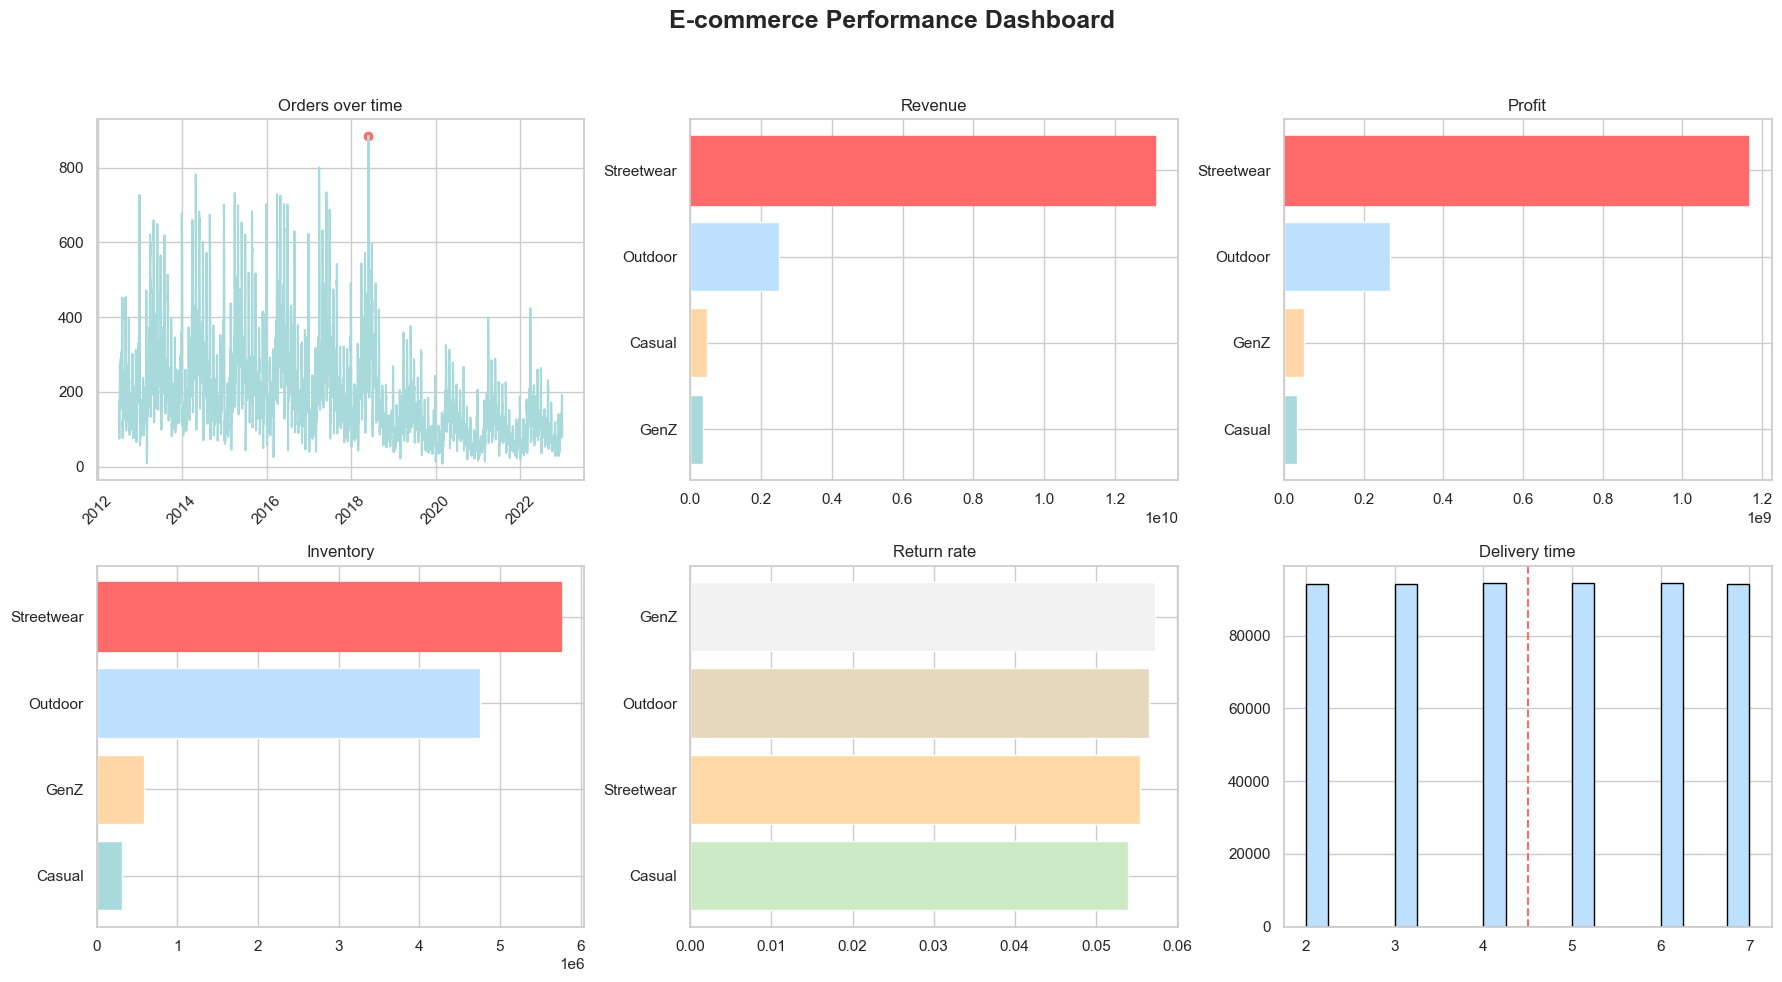

In [53]:
import seaborn as sns
sns.set_theme(style="whitegrid", context="notebook") # Thiết lập lại theme cho Phần 2
fig, axs = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("E-commerce Performance Dashboard", fontsize=18, fontweight='bold')

# Orders
axs[0, 0].plot(orders_time.index, orders_time.values, color=pastel_colors[0])
peak_day = orders_time.idxmax()
peak_val = orders_time.max()
axs[0, 0].scatter(peak_day, peak_val, color=highlight_color)
axs[0, 0].set_title("Orders over time")
axs[0, 0].tick_params(axis='x', rotation=45)

# Revenue
bars = axs[0, 1].barh(rev_cat.index, rev_cat.values, color=pastel_colors[:len(rev_cat)])
bars[-1].set_color(highlight_color)
axs[0, 1].set_title("Revenue")

# Profit
bars = axs[0, 2].barh(profit_cat.index, profit_cat.values, color=pastel_colors[:len(profit_cat)])
bars[-1].set_color(highlight_color)
axs[0, 2].set_title("Profit")

# Inventory
bars = axs[1, 0].barh(p2_inventory_cat.index, p2_inventory_cat.values, color=pastel_colors[:len(p2_inventory_cat)])
bars[-1].set_color(highlight_color)
axs[1, 0].set_title("Inventory")

# Return rate
colors_grad = plt.cm.Pastel1(np.linspace(0.3, 0.9, len(return_rate)))
axs[1, 1].barh(return_rate.index, return_rate.values, color=colors_grad)
axs[1, 1].set_title("Return rate")

# Delivery
axs[1, 2].hist(p2_shipments['delivery_time'], bins=20, color=pastel_colors[2], edgecolor='black')
mean_val = p2_shipments['delivery_time'].mean()
axs[1, 2].axvline(mean_val, color=highlight_color, linestyle='--')
axs[1, 2].set_title("Delivery time")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

#### **Analysis từ các Dashboard:**


##### **Chart 1 — Orders over time**

- Lượng đơn hàng **không đều** qua thời gian, có những đỉnh spike rõ rệt — gợi ý hoạt động kinh doanh chịu tác động mạnh bởi **campaign theo mùa vụ hoặc sự kiện khuyến mãi** (flash sale, double-day).
- Ngoài các đỉnh đó, baseline đơn hàng hàng ngày ở mức khá ổn định — nền tảng có **lượng khách hàng thường xuyên** nhất định.
- **Implication:** Cần chuẩn bị năng lực vận hành (kho, vận chuyển, nhân sự) theo chu kỳ spike, không theo mức trung bình.

##### **Chart 2 & 3 — Revenue & Profit by Category**

- Danh mục dẫn đầu về **doanh thu** không nhất thiết là danh mục dẫn đầu về **lợi nhuận** — biên lợi nhuận khác nhau đáng kể giữa các category.
- Nếu một category có revenue cao nhưng profit thấp, khả năng chi phí discount, COGS hoặc tỷ lệ hoàn hàng đang ăn mòn biên.
- **Implication:** Chiến lược pricing và khuyến mãi nên được thiết kế riêng theo category, tránh áp dụng đồng loạt discount vào các mặt hàng margin mỏng.


##### **Chart 4 — Inventory by Category**

- Nếu một category có **tồn kho lớn nhưng revenue thấp** — dấu hiệu overstock (dead stock, vốn bị chôn, tốn chi phí lưu kho).
- Ngược lại, category có demand cao nhưng inventory thấp — nguy cơ stockout, mất doanh thu cơ hội.
- **Implication:** Cần rebalance kế hoạch nhập hàng theo tỷ lệ sell-through thực tế.

##### **Chart 5 — Return Rate by Category**

- Danh mục có tỷ lệ hoàn hàng cao nhất là điểm nóng rủi ro vận hành — mỗi đơn hoàn không chỉ mất doanh thu mà còn phát sinh chi phí logistics ngược.
- Return rate cao thường liên quan đến: mô tả sản phẩm không khớp thực tế, chất lượng không đồng đều, hoặc thói quen mua thử-trả của một phân khúc khách hàng.
- **Implication:** Ưu tiên cải thiện product page và kiểm soát chất lượng tại category có return rate > 20%.

##### **Chart 6 — Delivery Time Distribution**

- Nếu phân phối có đuôi dài bên phải (long tail) — một bộ phận đơn hàng bị giao trễ đáng kể, ảnh hưởng trực tiếp đến satisfaction score và nguy cơ hoàn hàng.
- **Implication:** Xác định ngưỡng SLA giao hàng và theo dõi % đơn vi phạm SLA theo từng khu vực/carrier.


### **Phần B: Tổng kết insight**

**Descriptive — Thực trạng:**  
Lượng đơn hàng tăng trưởng theo thời gian với baseline ổn định, nhưng phân bổ doanh thu và lợi nhuận tập trung không đều giữa các danh mục sản phẩm. Tồn kho hiện tại chưa phản ánh đúng cơ cấu nhu cầu thực tế.

**Diagnostic — Nguyên nhân:**  
Sự chênh lệch giữa revenue và profit theo category cho thấy chi phí COGS, discount và tỷ lệ hoàn hàng phân hóa mạnh. Một số danh mục tạo volume lớn nhưng biên thực nhận thấp do chiết khấu cao hoặc chất lượng không đồng đều dẫn đến hoàn hàng.

**Predictive — Xu hướng:**  
Các spike đơn hàng theo sự kiện có tính lặp lại, cho phép dự báo nhu cầu theo mùa vụ. Category có return rate cao và tồn kho tồn đọng có nguy cơ kéo dài tình trạng kém hiệu quả nếu không được can thiệp.

**Prescriptive — Khuyến nghị:**  
Tái cân bằng kế hoạch nhập hàng và kiểm soát discount riêng theo từng danh mục. Ưu tiên cải thiện chất lượng sản phẩm và mô tả listing cho các category có return rate > 20%. Thiết lập SLA giao hàng và theo dõi tỷ lệ vi phạm theo khu vực để giảm thiểu đơn trễ.

# **PHẦN 3: Góc nhìn Marketing - Tăng trưởng**

**Business question chính:**  
Kênh marketing nào đang tạo tăng trưởng thật sự: kéo traffic, chuyển đổi thành đơn hàng, tạo doanh thu/lợi nhuận, giữ trải nghiệm khách hàng tốt, và nên được ưu tiên đầu tư?

#### 1. Data preparation: tạo bảng phân tích marketing

Ta cần nối các bảng:
- `orders`: đơn hàng, ngày, `order_source`
- `order_items`: sản phẩm trong đơn, giá sau giảm, khuyến mãi
- `products`: category/segment/COGS để tính biên lợi nhuận ước tính
- `payments`: payment value
- `web_traffic`: sessions, visitors, page views, bounce rate
- `reviews`, `returns`: chất lượng khách hàng và hậu mãi

In [54]:
orders = orders.copy()
order_items = order_items.copy()
web = web_traffic.copy()
promotions = promotions.copy()
reviews = reviews.copy()
returns = returns.copy()
products = pd.read_csv(DATA_DIR / 'products.csv', low_memory=False)
payments = payments.copy()
shipments = shipments.copy()
customers = customers.copy()
geo = geo.copy()

# Chuẩn hóa tháng
orders["year_month"] = orders["order_date"].dt.to_period("M").dt.to_timestamp()
orders["year"] = orders["order_date"].dt.year
orders["month"] = orders["order_date"].dt.month
web["year_month"] = web["date"].dt.to_period("M").dt.to_timestamp()
web["year"] = web["date"].dt.year
web["month"] = web["date"].dt.month

# Join order_items với product để tính revenue/margin ước tính
items = order_items.merge(
    products[["product_id", "product_name", "category", "segment", "size", "price", "cogs"]],
    on="product_id",
    how="left"
)

items["line_revenue"] = items["quantity"] * items["unit_price"]
items["gross_profit_est"] = items["quantity"] * (items["unit_price"] - items["cogs"])
items["has_promo"] = items["promo_id"].notna() | items["promo_id_2"].notna()

# Tổng hợp lên cấp order
order_value = items.groupby("order_id", as_index=False).agg(
    item_lines=("product_id", "count"),
    total_qty=("quantity", "sum"),
    order_revenue=("line_revenue", "sum"),
    order_discount=("discount_amount", "sum"),
    gross_profit_est=("gross_profit_est", "sum"),
    promo_lines=("has_promo", "sum")
)
order_value["has_any_promo"] = order_value["promo_lines"] > 0

orders_enriched = (
    orders
    .merge(order_value, on="order_id", how="left")
    .merge(payments[["order_id", "payment_value", "installments"]], on="order_id", how="left")
)

orders_enriched.head()

,order_id,order_date,customer_id,zip,order_status,payment_method,device_type,order_source,year_month,year,month,item_lines,total_qty,order_revenue,order_discount,gross_profit_est,promo_lines,has_any_promo,payment_value,installments
0,1,2012-07-04,58578,1109,delivered,credit_card,desktop,paid_search,2012-07-01,2012,7,1,7,"7,967.5400",0.0000,590.9539,0,False,"7,967.5400",3
1,2,2012-07-04,58621,1330,returned,cod,mobile,paid_search,2012-07-01,2012,7,1,7,"71,163.7500",0.0000,"8,249.8204",0,False,"71,163.7500",1
2,3,2012-07-04,58811,1473,delivered,credit_card,desktop,direct,2012-07-01,2012,7,1,3,"33,660.9900",0.0000,"3,387.9532",0,False,"33,660.9900",3
3,4,2012-07-04,59453,2360,delivered,credit_card,desktop,referral,2012-07-01,2012,7,1,5,"53,196.2500",0.0000,"7,169.0976",0,False,"53,196.2500",3
4,6,2012-07-06,57821,2886,delivered,paypal,mobile,email_campaign,2012-07-01,2012,7,1,1,"1,597.8400",0.0000,549.1436,0,False,"1,597.8400",1


In [55]:
# Quick data health check
print("Order date range:", orders_enriched["order_date"].min(), "to", orders_enriched["order_date"].max())
print("Web date range:", web["date"].min(), "to", web["date"].max())
print("\nMissing values in key columns:")
display(orders_enriched[["order_source", "order_revenue", "gross_profit_est", "has_any_promo"]].isna().mean().to_frame("missing_rate"))
display(web.isna().mean().to_frame("missing_rate"))

Order date range: 2012-07-04 00:00:00 to 2022-12-31 00:00:00
Web date range: 2013-01-01 00:00:00 to 2022-12-31 00:00:00

Missing values in key columns:


,missing_rate
order_source,0.0000
order_revenue,0.0000
gross_profit_est,0.0000
has_any_promo,0.0000


,missing_rate
date,0.0000
sessions,0.0000
unique_visitors,0.0000
page_views,0.0000
bounce_rate,0.0000
avg_session_duration_sec,0.0000
traffic_source,0.0000
year_month,0.0000
year,0.0000
month,0.0000


In [56]:
# 1. TẠO monthly_orders
monthly_orders = orders_enriched.groupby(
    ["year_month", "order_source"], as_index=False
).agg(
    orders=("order_id", "count"),
    revenue=("order_revenue", "sum"),
    gross_profit=("gross_profit_est", "sum")
)

# 2. TẠO monthly_web
monthly_web = web.groupby(
    ["year_month", "traffic_source"], as_index=False
).agg(
    sessions=("sessions", "sum"),
    unique_visitors=("unique_visitors", "sum"),
    page_views=("page_views", "sum"),
    bounce_rate=("bounce_rate", "mean"),
    avg_session_duration_sec=("avg_session_duration_sec", "mean")
)

# 3. MERGE → TẠO funnel
funnel = monthly_web.merge(
    monthly_orders,
    left_on=["year_month", "traffic_source"],
    right_on=["year_month", "order_source"],
    how="left"
)

# Fill NaN
funnel["orders"] = funnel["orders"].fillna(0)
funnel["revenue"] = funnel["revenue"].fillna(0)
funnel["gross_profit"] = funnel["gross_profit"].fillna(0)

# Metrics
funnel["conversion_proxy"] = funnel["orders"] / funnel["sessions"]
funnel["revenue_per_session"] = funnel["revenue"] / funnel["sessions"]
funnel["profit_per_session"] = funnel["gross_profit"] / funnel["sessions"]

### **PART A — Visualization**

Các câu hỏi đặt ra:
1. Kênh nào đang đóng góp nhiều nhất?
2. Kênh nào hiệu quả nhất?
3. Vì sao hiệu quả khác nhau?
4. Tăng trưởng/mùa vụ đang diễn ra thế nào?
5. Khuyến mãi và trải nghiệm khách hàng ảnh hưởng ra sao?
6. Nên làm gì?

#### Visualization 1 — Channel contribution: Orders, Revenue, Gross Profit

**Mục tiêu:** trả lời cấp **Descriptive**: kênh marketing nào đang tạo volume và doanh thu lớn nhất?

,order_source,orders,revenue,gross_profit,aov,avg_margin_per_order,order_share,revenue_share,profit_share
2,organic_search,"181,495","4,595,516,711","635,104,309","25,320","3,499",28.1%,28.0%,28.0%
3,paid_search,"141,652","3,606,943,187","496,923,803","25,463","3,508",21.9%,22.0%,21.9%
5,social_media,"129,710","3,289,598,708","453,262,171","25,361","3,494",20.0%,20.0%,20.0%
1,email_campaign,"77,572","1,972,621,080","274,454,703","25,430","3,538",12.0%,12.0%,12.1%
4,referral,"64,565","1,640,764,180","223,848,074","25,413","3,467",10.0%,10.0%,9.9%
0,direct,"51,951","1,325,032,720","183,433,006","25,505","3,531",8.0%,8.1%,8.1%


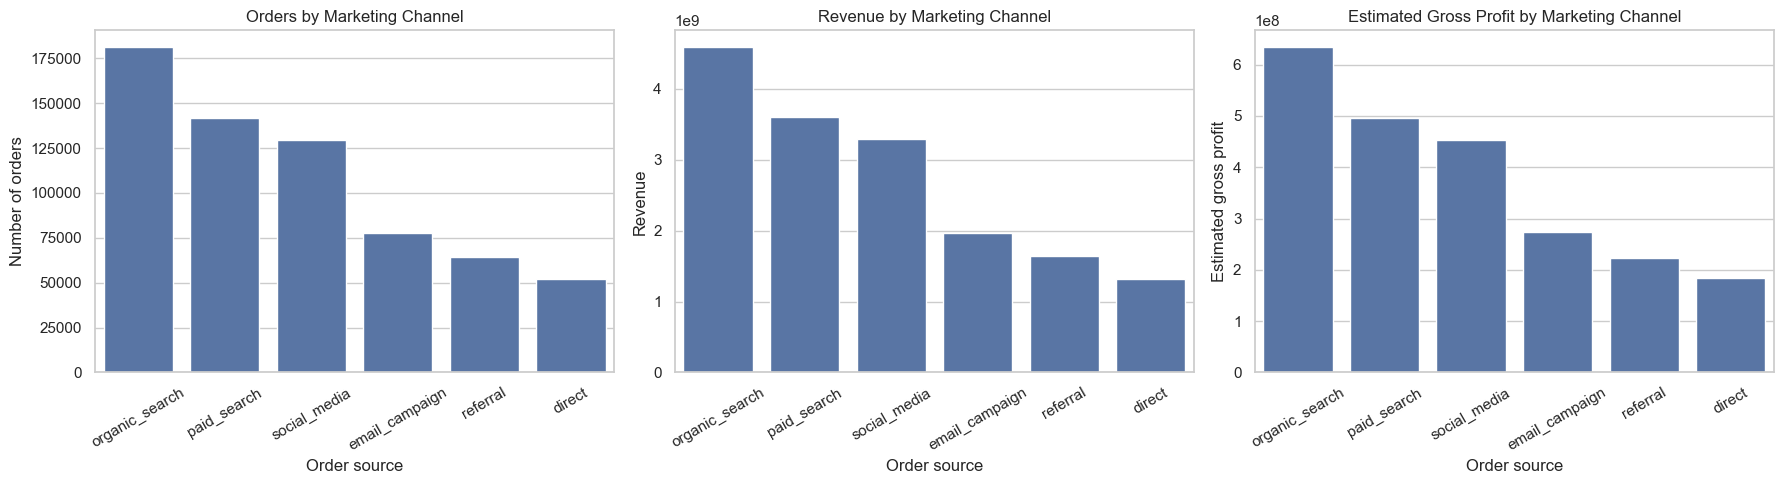

In [57]:
channel_summary = orders_enriched.groupby("order_source", as_index=False).agg(
    orders=("order_id", "count"),
    revenue=("order_revenue", "sum"),
    gross_profit=("gross_profit_est", "sum"),
    aov=("order_revenue", "mean"),
    avg_margin_per_order=("gross_profit_est", "mean")
)

channel_summary["order_share"] = channel_summary["orders"] / channel_summary["orders"].sum()
channel_summary["revenue_share"] = channel_summary["revenue"] / channel_summary["revenue"].sum()
channel_summary["profit_share"] = channel_summary["gross_profit"] / channel_summary["gross_profit"].sum()
channel_summary = channel_summary.sort_values("revenue", ascending=False)

display(channel_summary.style.format({
    "orders": "{:,.0f}",
    "revenue": "{:,.0f}",
    "gross_profit": "{:,.0f}",
    "aov": "{:,.0f}",
    "avg_margin_per_order": "{:,.0f}",
    "order_share": "{:.1%}",
    "revenue_share": "{:.1%}",
    "profit_share": "{:.1%}",
}))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=channel_summary, x="order_source", y="orders", ax=axes[0])
axes[0].set_title("Orders by Marketing Channel")
axes[0].set_xlabel("Order source")
axes[0].set_ylabel("Number of orders")
axes[0].tick_params(axis="x", rotation=30)

sns.barplot(data=channel_summary, x="order_source", y="revenue", ax=axes[1])
axes[1].set_title("Revenue by Marketing Channel")
axes[1].set_xlabel("Order source")
axes[1].set_ylabel("Revenue")
axes[1].tick_params(axis="x", rotation=30)

sns.barplot(data=channel_summary, x="order_source", y="gross_profit", ax=axes[2])
axes[2].set_title("Estimated Gross Profit by Marketing Channel")
axes[2].set_xlabel("Order source")
axes[2].set_ylabel("Estimated gross profit")
axes[2].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

#### **Analysis 1 — Descriptive insight**

- `organic_search` là kênh lớn nhất về **đơn hàng**, **doanh thu** và **gross profit ước tính**.
- Ba kênh lớn nhất thường là `organic_search`, `paid_search`, `social_media`, chiếm phần lớn tăng trưởng.
- Tuy nhiên, `AOV` giữa các kênh không chênh quá mạnh, nghĩa là khác biệt doanh thu chủ yếu đến từ **volume**, không phải do mỗi đơn hàng của kênh này đắt hơn hẳn kênh khác.

**Business implication:**  
Marketing không nên chỉ nhìn vào doanh thu tổng. Cần tách rõ:
- Kênh tạo volume lớn: phù hợp để scale.
- Kênh có hiệu quả chuyển đổi/lợi nhuận tốt: phù hợp để tối ưu ROI.

#### **Visualization 2 — Traffic funnel: Sessions → Orders → Revenue**

**Mục tiêu:** cấp **Diagnostic**: kênh nào kéo nhiều traffic nhưng chuyển đổi chưa tương xứng?

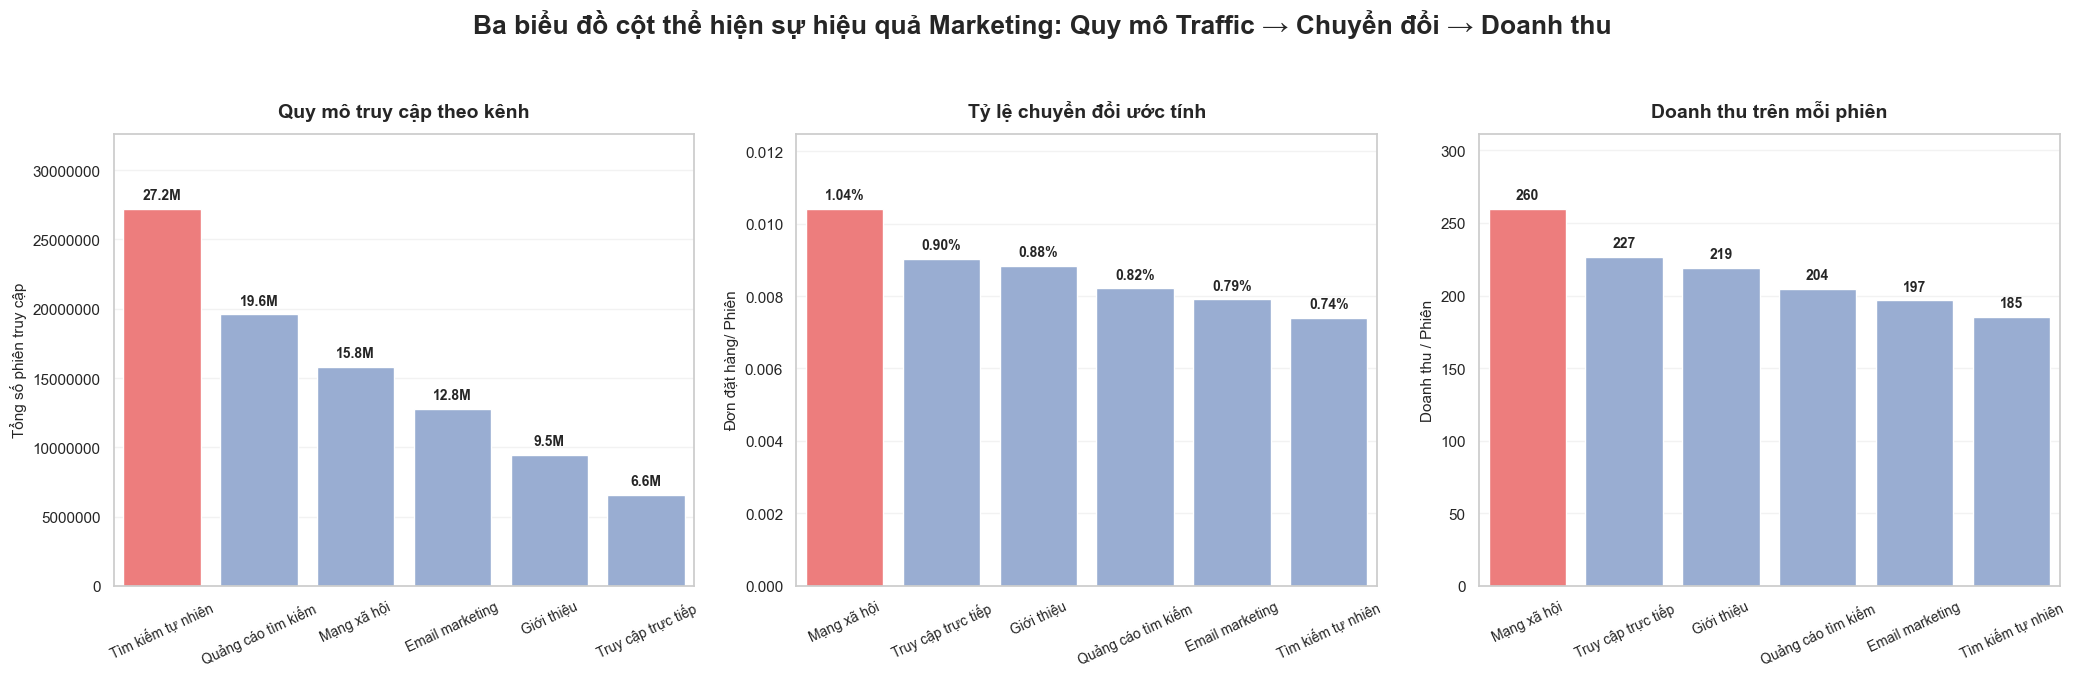

,traffic_source,traffic_source_vi,sessions,orders,revenue,gross_profit,conversion_proxy,revenue_per_session,profit_per_session
5,social_media,Mạng xã hội,"15,816,226","123,261","3,141,422,009","422,495,469",1.040%,259.58,33.85
0,direct,Truy cập trực tiếp,"6,571,549","42,891","1,100,009,291","149,765,843",0.902%,226.61,30.76
4,referral,Giới thiệu,"9,476,845","59,052","1,513,127,797","203,118,023",0.884%,218.78,29.55
3,paid_search,Quảng cáo tìm kiếm,"19,598,271","134,668","3,441,723,469","462,631,315",0.821%,204.39,27.23
1,email_campaign,Email marketing,"12,792,670","71,524","1,834,472,984","249,743,296",0.791%,196.67,27.22
2,organic_search,Tìm kiếm tự nhiên,"27,196,976","172,474","4,387,682,612","591,367,204",0.739%,185.38,25.63


In [58]:
# FUNNEL SUMMARY: WEB TRAFFIC + ORDERS

funnel_summary = funnel.groupby("traffic_source", as_index=False).agg(
    sessions=("sessions", "sum"),
    orders=("orders", "sum"),
    revenue=("revenue", "sum"),
    gross_profit=("gross_profit", "sum"),
    conversion_proxy=("conversion_proxy", "mean"),
    revenue_per_session=("revenue_per_session", "mean"),
    profit_per_session=("profit_per_session", "mean"),
)

source_labels = {
    "organic_search": "Tìm kiếm tự nhiên",
    "paid_search": "Quảng cáo tìm kiếm",
    "social_media": "Mạng xã hội",
    "email_campaign": "Email marketing",
    "referral": "Giới thiệu",
    "direct": "Truy cập trực tiếp"
}

# Sửa lỗi ở đây: dùng traffic_source, không dùng order_source
funnel_summary["traffic_source_vi"] = funnel_summary["traffic_source"].map(source_labels)

# Nếu có kênh nào không map được thì giữ tên gốc
funnel_summary["traffic_source_vi"] = funnel_summary["traffic_source_vi"].fillna(
    funnel_summary["traffic_source"]
)

# VISUALIZATION: MARKETING FUNNEL

fig, axes = plt.subplots(1, 3, figsize=(21, 6.5))

fig.suptitle(
    "Ba biểu đồ cột thể hiện sự hiệu quả Marketing: Quy mô Traffic → Chuyển đổi → Doanh thu",
    fontsize=19,
    fontweight="bold",
    y=1.04
)

plots = [
    {
        "ax": axes[0],
        "data": funnel_summary.sort_values("sessions", ascending=False),
        "x": "traffic_source_vi",
        "y": "sessions",
        "title": "Quy mô truy cập theo kênh",
        "ylabel": "Tổng số phiên truy cập",
        "fmt": lambda v: f"{v/1_000_000:.1f}M"
    },
    {
        "ax": axes[1],
        "data": funnel_summary.sort_values("conversion_proxy", ascending=False),
        "x": "traffic_source_vi",
        "y": "conversion_proxy",
        "title": "Tỷ lệ chuyển đổi ước tính",
        "ylabel": "Đơn đặt hàng/ Phiên",
        "fmt": lambda v: f"{v:.2%}"
    },
    {
        "ax": axes[2],
        "data": funnel_summary.sort_values("revenue_per_session", ascending=False),
        "x": "traffic_source_vi",
        "y": "revenue_per_session",
        "title": "Doanh thu trên mỗi phiên",
        "ylabel": "Doanh thu / Phiên",
        "fmt": lambda v: f"{v:,.0f}"
    }
]

for p in plots:
    ax = p["ax"]
    data = p["data"].copy()

    colors = ["#FF6B6B" if i == 0 else "#8FAADC" for i in range(len(data))]

    sns.barplot(
        data=data,
        x=p["x"],
        y=p["y"],
        ax=ax,
        palette=colors
    )

    ax.set_title(p["title"], fontsize=14, fontweight="bold", pad=12)
    ax.set_xlabel("")
    ax.set_ylabel(p["ylabel"], fontsize=11)
    ax.tick_params(axis="x", rotation=25, labelsize=10)
    ax.grid(axis="y", alpha=0.25)

    # Bỏ dạng 1e7 trên trục y
    ax.ticklabel_format(style="plain", axis="y")

    max_val = data[p["y"]].max()

    for container in ax.containers:
        for bar in container:
            height = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height + max_val * 0.018,
                p["fmt"](height),
                ha="center",
                va="bottom",
                fontsize=10,
                fontweight="bold"
            )

    ax.set_ylim(0, max_val * 1.20)

plt.tight_layout()
plt.show()

# DISPLAY TABLE

display(
    funnel_summary[[
        "traffic_source",
        "traffic_source_vi",
        "sessions",
        "orders",
        "revenue",
        "gross_profit",
        "conversion_proxy",
        "revenue_per_session",
        "profit_per_session"
    ]]
    .sort_values("profit_per_session", ascending=False)
    .style.format({
        "sessions": "{:,.0f}",
        "orders": "{:,.0f}",
        "revenue": "{:,.0f}",
        "gross_profit": "{:,.0f}",
        "conversion_proxy": "{:.3%}",
        "revenue_per_session": "{:,.2f}",
        "profit_per_session": "{:,.2f}",
    })
)

#### Analysis 2 — Diagnostic insight

- `organic_search` dẫn đầu về tổng sessions và tổng revenue, nhưng chưa chắc dẫn đầu về **conversion proxy**.
- Các kênh nhỏ hơn như `social_media`, `direct`, hoặc `referral` có thể có conversion proxy/revenue per session cạnh tranh hơn.
- Điều này cho thấy có hai loại kênh:
  1. **Scale channels**: tạo volume lớn, ví dụ organic/paid/social.
  2. **Efficiency channels**: traffic ít hơn nhưng tỷ lệ chuyển đổi tốt hơn.

**Business implication:**  
Không nên phân bổ ngân sách chỉ theo tổng revenue. Cần tối ưu theo **revenue per session** và **profit per session** để biết kênh nào thật sự hiệu quả trên từng lượt truy cập.

#### **Visualization 3 — Monthly trend & channel growth over time**

**Mục tiêu:** cấp **Predictive**: kênh nào đang có xu hướng tăng/giảm, và tăng trưởng có bền vững không?

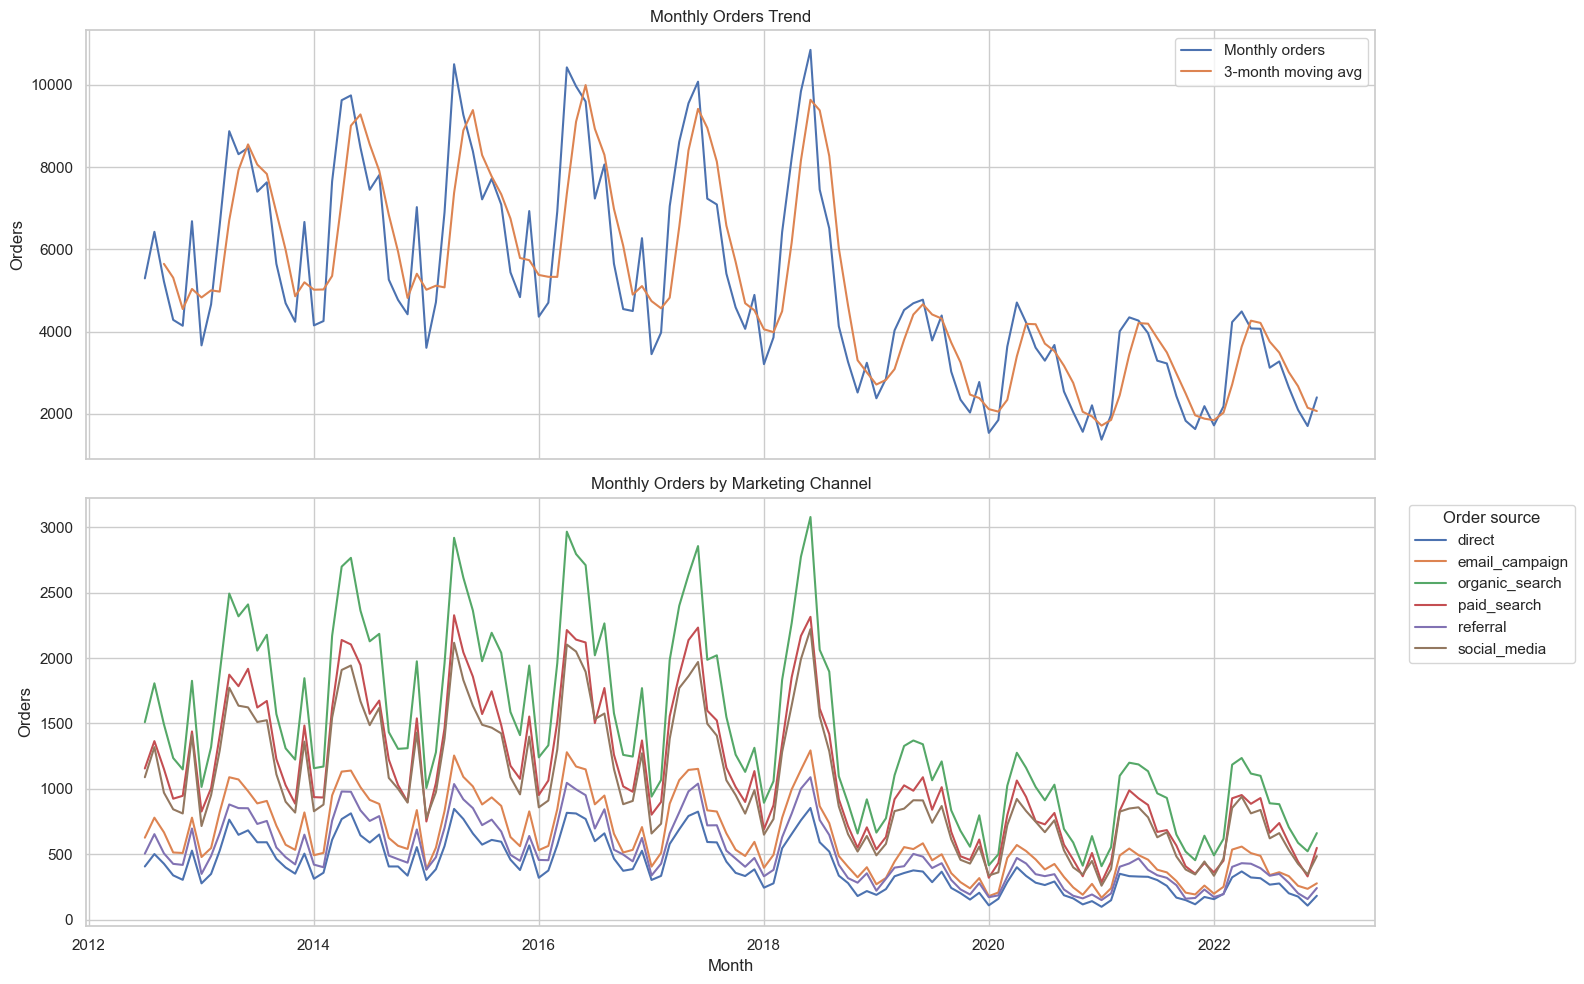

In [59]:
monthly_channel = orders_enriched.groupby(["year_month", "order_source"], as_index=False).agg(
    orders=("order_id", "count"),
    revenue=("order_revenue", "sum")
)

monthly_total = orders_enriched.groupby("year_month", as_index=False).agg(
    orders=("order_id", "count"),
    revenue=("order_revenue", "sum")
)
monthly_total["orders_ma3"] = monthly_total["orders"].rolling(3).mean()
monthly_total["revenue_ma3"] = monthly_total["revenue"].rolling(3).mean()

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

sns.lineplot(data=monthly_total, x="year_month", y="orders", ax=axes[0], label="Monthly orders")
sns.lineplot(data=monthly_total, x="year_month", y="orders_ma3", ax=axes[0], label="3-month moving avg")
axes[0].set_title("Monthly Orders Trend")
axes[0].set_xlabel("")
axes[0].set_ylabel("Orders")

sns.lineplot(data=monthly_channel, x="year_month", y="orders", hue="order_source", ax=axes[1])
axes[1].set_title("Monthly Orders by Marketing Channel")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Orders")
axes[1].legend(title="Order source", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

year,order_source,yoy_orders_2022_vs_2021
1,email_campaign,6.2%
5,social_media,5.8%
0,direct,5.1%
3,paid_search,4.7%
2,organic_search,2.6%
4,referral,2.2%


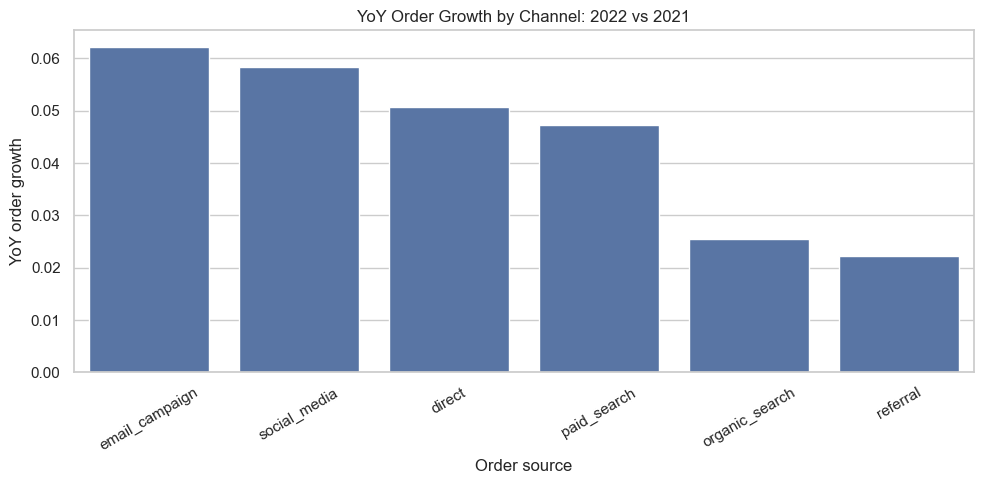

In [60]:
# YoY growth by channel: 2022 vs 2021
annual_channel = orders_enriched.groupby(["year", "order_source"], as_index=False).agg(
    orders=("order_id", "count"),
    revenue=("order_revenue", "sum")
)

pivot_orders = annual_channel.pivot(index="order_source", columns="year", values="orders")
if 2021 in pivot_orders.columns and 2022 in pivot_orders.columns:
    pivot_orders["yoy_orders_2022_vs_2021"] = (pivot_orders[2022] - pivot_orders[2021]) / pivot_orders[2021]
    yoy = pivot_orders[["yoy_orders_2022_vs_2021"]].reset_index().sort_values("yoy_orders_2022_vs_2021", ascending=False)
else:
    yoy = pd.DataFrame()

display(yoy.style.format({"yoy_orders_2022_vs_2021": "{:.1%}"}))

plt.figure(figsize=(10, 5))
sns.barplot(data=yoy, x="order_source", y="yoy_orders_2022_vs_2021")
plt.title("YoY Order Growth by Channel: 2022 vs 2021")
plt.xlabel("Order source")
plt.ylabel("YoY order growth")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

#### Analysis 3 — Predictive insight

- Tổng orders có xu hướng tăng dài hạn theo thời gian, nhưng tốc độ tăng giữa các kênh không giống nhau.
- Biểu đồ YoY giúp nhận diện kênh đang tăng nhanh gần cuối giai đoạn train. Đây là tín hiệu quan trọng để dự đoán kênh nào sẽ tiếp tục đóng góp tăng trưởng trong giai đoạn sau.
- Nếu một kênh có base nhỏ nhưng YoY growth cao, đó có thể là **growth opportunity**.
- Nếu một kênh lớn nhưng YoY growth thấp, đó là **mature channel**: vẫn quan trọng nhưng cần tối ưu chi phí/hiệu quả.

**Business implication:**  
Kế hoạch marketing nên chia ngân sách theo vai trò:
- `organic_search`: duy trì nền tăng trưởng dài hạn.
- `paid_search`/`social_media`: dùng để scale có kiểm soát.
- `email_campaign`: khai thác retention/cross-sell vì đây là kênh có thể tăng trưởng với chi phí thấp.

#### **Visualization 4 — Seasonality heatmap: tháng nào đáng đẩy campaign?**

**Mục tiêu:** cấp **Predictive + Prescriptive**: nhận diện mùa vụ để lập lịch campaign.

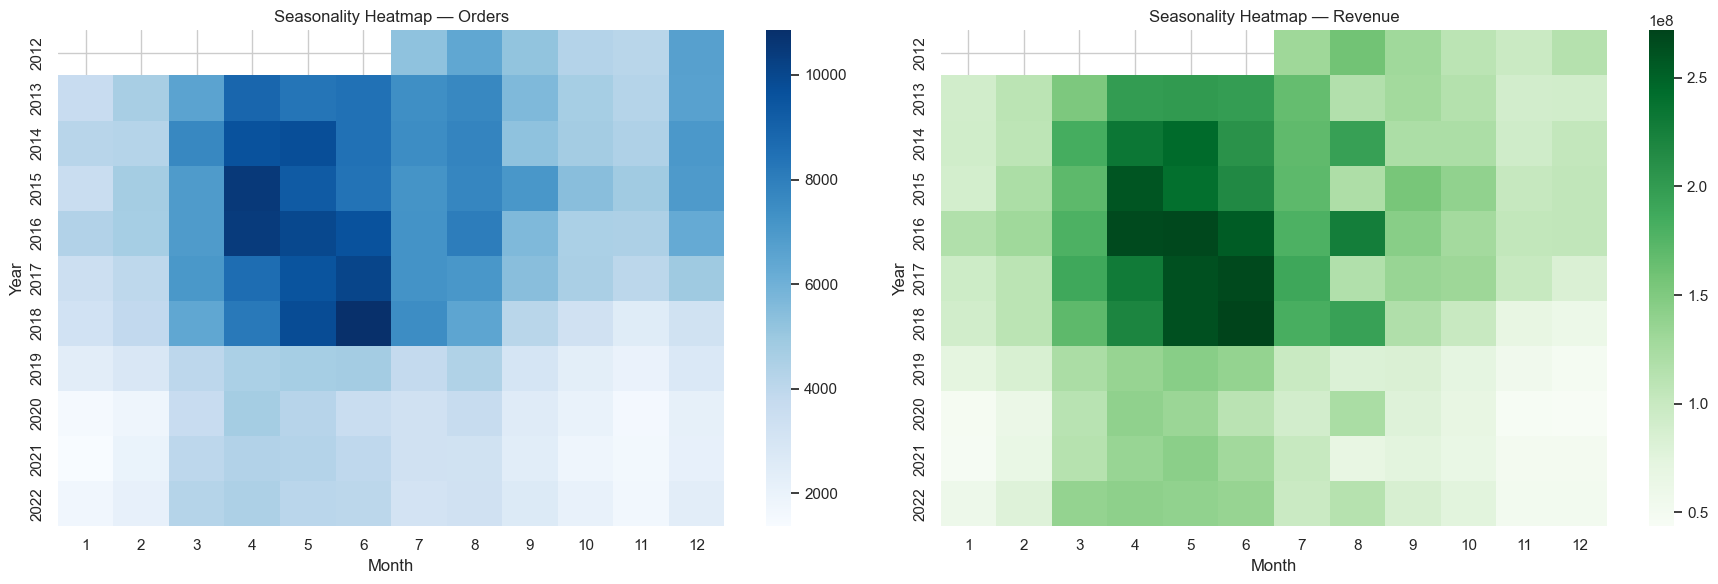

,month,avg_orders,avg_revenue,n_years,avg_orders_per_year,avg_revenue_per_year
3,4,"74,335","1,959,885,565",10,"7,434","195,988,556"
4,5,"73,943","2,038,379,068",10,"7,394","203,837,907"
5,6,"72,270","1,928,132,596",10,"7,227","192,813,260"
7,8,"65,811","1,514,446,980",11,"5,983","137,676,998"
2,3,"57,440","1,527,737,497",10,"5,744","152,773,750"
6,7,"62,776","1,575,008,809",11,"5,707","143,182,619"
11,12,"51,280","860,803,221",11,"4,662","78,254,838"
8,9,"49,054","1,253,282,449",11,"4,459","113,934,768"
9,10,"39,903","1,126,229,300",11,"3,628","102,384,482"
1,2,"35,031","981,585,819",10,"3,503","98,158,582"


In [61]:
seasonality = orders_enriched.groupby(["year", "month"], as_index=False).agg(
    orders=("order_id", "count"),
    revenue=("order_revenue", "sum")
)

heat_orders = seasonality.pivot(index="year", columns="month", values="orders")
heat_revenue = seasonality.pivot(index="year", columns="month", values="revenue")

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.heatmap(heat_orders, cmap="Blues", annot=False, fmt=".0f", ax=axes[0])
axes[0].set_title("Seasonality Heatmap — Orders")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Year")

sns.heatmap(heat_revenue, cmap="Greens", annot=False, fmt=".0f", ax=axes[1])
axes[1].set_title("Seasonality Heatmap — Revenue")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Year")

plt.tight_layout()
plt.show()

month_avg = orders_enriched.groupby("month", as_index=False).agg(
    avg_orders=("order_id", "count"),
    avg_revenue=("order_revenue", "sum")
)
# Vì groupby count/sum trên toàn bộ giai đoạn, ta chuẩn hóa bằng số năm xuất hiện mỗi tháng
month_year_counts = orders_enriched.groupby("month")["year"].nunique().rename("n_years").reset_index()
month_avg = month_avg.merge(month_year_counts, on="month")
month_avg["avg_orders_per_year"] = month_avg["avg_orders"] / month_avg["n_years"]
month_avg["avg_revenue_per_year"] = month_avg["avg_revenue"] / month_avg["n_years"]

display(month_avg.sort_values("avg_orders_per_year", ascending=False).style.format({
    "avg_orders": "{:,.0f}",
    "avg_revenue": "{:,.0f}",
    "avg_orders_per_year": "{:,.0f}",
    "avg_revenue_per_year": "{:,.0f}"
}))

##### **Analysis 4 — Predictive/Prescriptive insight**

- Heatmap giúp xác định tháng cao điểm/thấp điểm theo lịch sử.
- Tháng có orders/revenue cao nên được chuẩn bị trước bằng:
  - ngân sách paid media,
  - tồn kho,
  - vận chuyển,
  - landing page,
  - chiến dịch remarketing.
- Tháng thấp điểm không nhất thiết phải giảm marketing, mà có thể dùng **promo có chọn lọc** để kích cầu nếu biên lợi nhuận còn đủ.

**Business implication:**  
Campaign calendar nên được lập theo mùa vụ, không chạy ngân sách đều quanh năm. Nếu tháng cao điểm bị thiếu tồn kho hoặc logistics quá tải, doanh nghiệp sẽ mất cơ hội tăng trưởng.

#### Visualization 5 — Promotion effectiveness: khuyến mãi có tạo tăng trưởng chất lượng không?

**Mục tiêu:** cấp **Diagnostic + Prescriptive**: khuyến mãi có đang kéo volume nhưng làm giảm revenue/margin không?

,has_promo,lines,quantity,revenue,avg_line_revenue,avg_discount,avg_gross_profit,line_share,revenue_share
0,False,"438,353","1,971,104","10,995,039,053","25,083",0,"5,007",61.3%,66.9%
1,True,"276,316","1,242,039","5,435,437,533","19,671","2,713",261,38.7%,33.1%


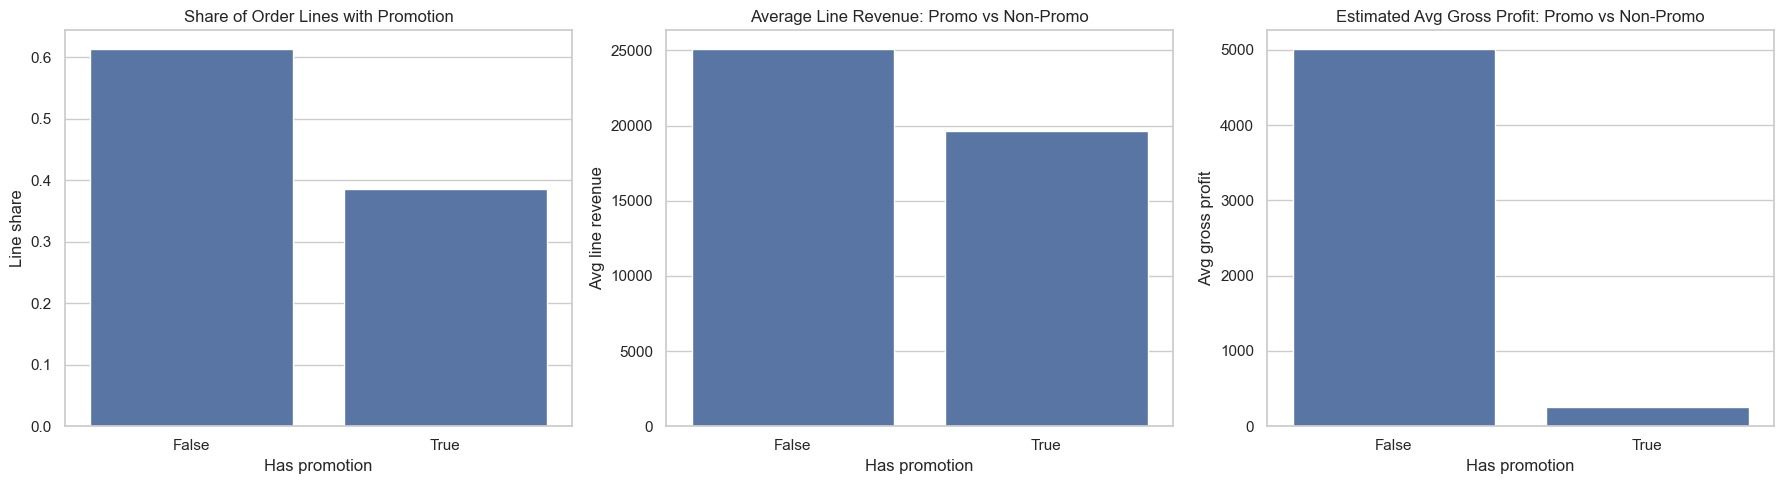

In [62]:
promo_eff = items.groupby("has_promo", as_index=False).agg(
    lines=("order_id", "count"),
    quantity=("quantity", "sum"),
    revenue=("line_revenue", "sum"),
    avg_line_revenue=("line_revenue", "mean"),
    avg_discount=("discount_amount", "mean"),
    avg_gross_profit=("gross_profit_est", "mean"),
)
promo_eff["line_share"] = promo_eff["lines"] / promo_eff["lines"].sum()
promo_eff["revenue_share"] = promo_eff["revenue"] / promo_eff["revenue"].sum()

display(promo_eff.style.format({
    "lines": "{:,.0f}",
    "quantity": "{:,.0f}",
    "revenue": "{:,.0f}",
    "avg_line_revenue": "{:,.0f}",
    "avg_discount": "{:,.0f}",
    "avg_gross_profit": "{:,.0f}",
    "line_share": "{:.1%}",
    "revenue_share": "{:.1%}",
}))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=promo_eff, x="has_promo", y="line_share", ax=axes[0])
axes[0].set_title("Share of Order Lines with Promotion")
axes[0].set_xlabel("Has promotion")
axes[0].set_ylabel("Line share")

sns.barplot(data=promo_eff, x="has_promo", y="avg_line_revenue", ax=axes[1])
axes[1].set_title("Average Line Revenue: Promo vs Non-Promo")
axes[1].set_xlabel("Has promotion")
axes[1].set_ylabel("Avg line revenue")

sns.barplot(data=promo_eff, x="has_promo", y="avg_gross_profit", ax=axes[2])
axes[2].set_title("Estimated Avg Gross Profit: Promo vs Non-Promo")
axes[2].set_xlabel("Has promotion")
axes[2].set_ylabel("Avg gross profit")

plt.tight_layout()
plt.show()

,order_source,has_promo,lines,revenue,avg_line_revenue,avg_gross_profit
0,direct,False,"35,061","882,131,490","25,160","5,046"
1,direct,True,"22,268","442,901,229","19,890",292
2,email_campaign,False,"52,482","1,318,424,999","25,121","5,002"
3,email_campaign,True,"33,367","654,196,081","19,606",358
4,organic_search,False,"123,034","3,073,432,256","24,980","5,009"
5,organic_search,True,"77,395","1,522,084,455","19,666",243
6,paid_search,False,"96,055","2,412,534,010","25,116","5,013"
7,paid_search,True,"60,445","1,194,409,176","19,760",255
8,referral,False,"43,733","1,097,479,524","25,095","4,971"
9,referral,True,"27,523","543,284,655","19,739",234


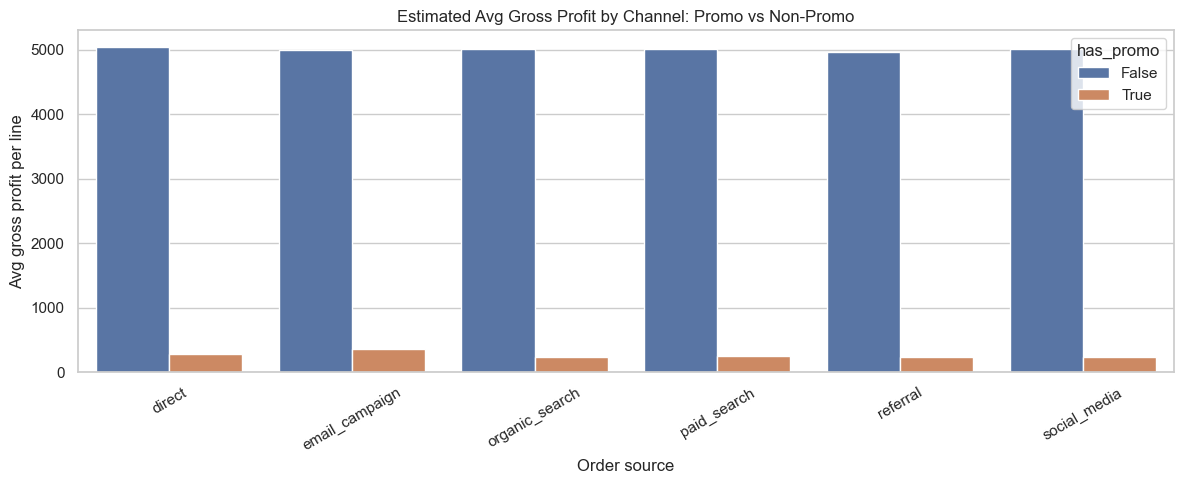

In [63]:
# Promo impact by channel
items_with_source = items.merge(
    orders[["order_id", "order_source", "order_date", "year_month"]],
    on="order_id",
    how="left"
)

promo_channel = items_with_source.groupby(["order_source", "has_promo"], as_index=False).agg(
    lines=("order_id", "count"),
    revenue=("line_revenue", "sum"),
    avg_line_revenue=("line_revenue", "mean"),
    avg_gross_profit=("gross_profit_est", "mean"),
)

display(promo_channel.sort_values(["order_source", "has_promo"]).style.format({
    "lines": "{:,.0f}",
    "revenue": "{:,.0f}",
    "avg_line_revenue": "{:,.0f}",
    "avg_gross_profit": "{:,.0f}",
}))

plt.figure(figsize=(12, 5))
sns.barplot(data=promo_channel, x="order_source", y="avg_gross_profit", hue="has_promo")
plt.title("Estimated Avg Gross Profit by Channel: Promo vs Non-Promo")
plt.xlabel("Order source")
plt.ylabel("Avg gross profit per line")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

##### **Analysis 5 — Diagnostic/Prescriptive insight**

- Một tỷ lệ lớn dòng order có áp dụng khuyến mãi, nhưng dòng có promo thường có **average line revenue** và **gross profit ước tính** thấp hơn dòng không promo.
- Điều này không có nghĩa promo “xấu”, mà nghĩa là promo cần được đánh giá theo mục tiêu:
  - Nếu mục tiêu là tăng volume/xả hàng: promo có thể hợp lý.
  - Nếu mục tiêu là lợi nhuận: promo đại trà có thể làm mỏng margin.
- Khi tách theo `order_source`, ta có thể thấy kênh nào bị ảnh hưởng margin mạnh hơn khi dùng promo.

**Business implication:**  
Không nên chạy discount đồng loạt. Nên áp dụng:
1. Promo cho kênh có conversion thấp nhưng traffic cao để kích hoạt mua hàng.
2. Promo cho sản phẩm tồn kho cao hoặc mùa thấp điểm.
3. Hạn chế promo ở kênh đã có conversion tốt nếu không cần thiết.

#### **Visualization 6 — Category/channel mix: kênh nào bán tốt nhóm sản phẩm nào?**

**Mục tiêu:** cấp **Diagnostic + Prescriptive**: cá nhân hóa thông điệp marketing theo sản phẩm.

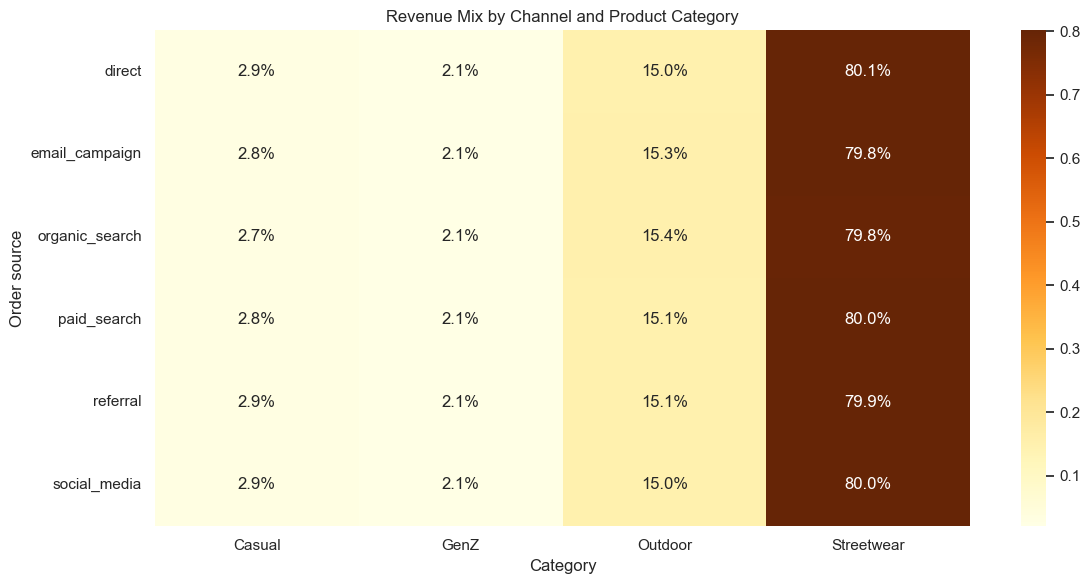

category,Casual,GenZ,Outdoor,Streetwear
order_source,,,,
direct,2.9%,2.1%,15.0%,80.1%
email_campaign,2.8%,2.1%,15.3%,79.8%
organic_search,2.7%,2.1%,15.4%,79.8%
paid_search,2.8%,2.1%,15.1%,80.0%
referral,2.9%,2.1%,15.1%,79.9%
social_media,2.9%,2.1%,15.0%,80.0%


In [64]:
category_channel = items_with_source.groupby(["order_source", "category"], as_index=False).agg(
    revenue=("line_revenue", "sum"),
    quantity=("quantity", "sum"),
    avg_gross_profit=("gross_profit_est", "mean")
)

mix = category_channel.pivot(index="order_source", columns="category", values="revenue").fillna(0)
mix_share = mix.div(mix.sum(axis=1), axis=0)

plt.figure(figsize=(12, 6))
sns.heatmap(mix_share, annot=True, fmt=".1%", cmap="YlOrBr")
plt.title("Revenue Mix by Channel and Product Category")
plt.xlabel("Category")
plt.ylabel("Order source")
plt.tight_layout()
plt.show()

display(mix_share.style.format("{:.1%}"))

##### **Analysis 6 — Diagnostic/Prescriptive insight**

- Mỗi kênh có thể có product mix khác nhau.
- Nếu một kênh bán mạnh một category nhất định, thông điệp quảng cáo nên nhấn vào category đó thay vì dùng cùng một creative cho mọi kênh.
- Nếu category có margin cao xuất hiện mạnh ở một kênh, kênh đó có thể là nơi tốt để scale lợi nhuận.

**Business implication:**  
Đề xuất chạy campaign theo ma trận:
- `channel × category × margin`
thay vì chỉ chạy campaign theo channel tổng quát.

##### **Visualization 7 — Lag analysis: traffic hôm nay có báo trước orders tháng sau không?**

**Mục tiêu:** cấp **Predictive**: kiểm tra xem traffic có thể là leading indicator cho đơn hàng tương lai không.

,traffic_source,corr_sessions_same_month_orders,corr_sessions_next_month_orders
5,social_media,0.246,0.170
3,paid_search,0.266,0.160
1,email_campaign,0.128,0.085
4,referral,0.196,0.084
0,direct,0.113,0.012
2,organic_search,0.154,-0.003


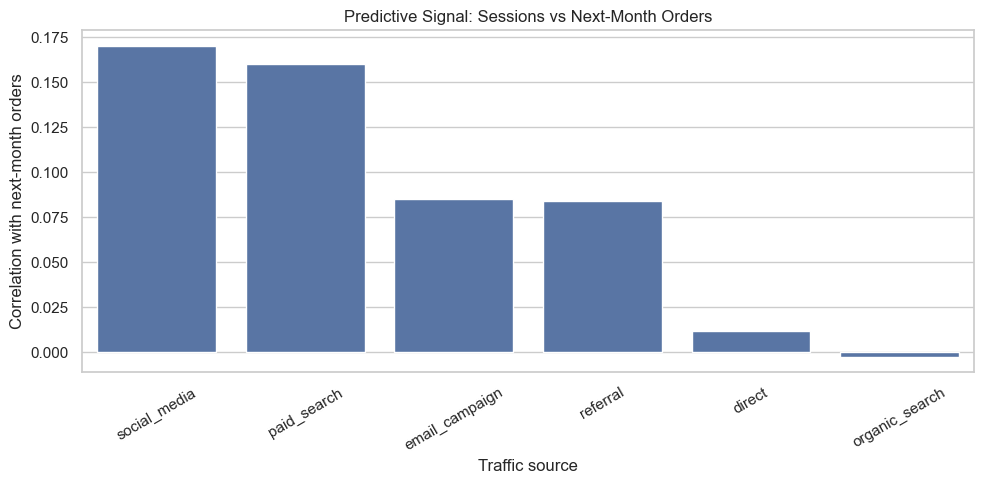

In [65]:
lag_results = []

for src, g in funnel.sort_values("year_month").groupby("traffic_source"):
    g = g.sort_values("year_month").copy()
    same_month_corr = g["sessions"].corr(g["orders"])
    next_month_corr = g["sessions"].corr(g["orders"].shift(-1))
    lag_results.append({
        "traffic_source": src,
        "corr_sessions_same_month_orders": same_month_corr,
        "corr_sessions_next_month_orders": next_month_corr,
    })

lag_df = pd.DataFrame(lag_results).sort_values("corr_sessions_next_month_orders", ascending=False)

display(lag_df.style.format({
    "corr_sessions_same_month_orders": "{:.3f}",
    "corr_sessions_next_month_orders": "{:.3f}",
}))

plt.figure(figsize=(10, 5))
sns.barplot(data=lag_df, x="traffic_source", y="corr_sessions_next_month_orders")
plt.title("Predictive Signal: Sessions vs Next-Month Orders")
plt.xlabel("Traffic source")
plt.ylabel("Correlation with next-month orders")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

##### **Analysis 7 — Predictive insight**

- Nếu một kênh có tương quan dương giữa sessions tháng này và orders tháng sau, traffic của kênh đó có thể dùng như **leading indicator**.
- Nếu correlation thấp, traffic của kênh đó có thể chuyển đổi nhanh trong cùng tháng hoặc bị nhiễu bởi yếu tố khác như promo, mùa vụ, tồn kho, logistics.
- Đây là phân tích dự báo đơn giản nhưng rất hữu ích để đưa vào report vì nó nối marketing metrics với planning.

**Business implication:**  
Kênh có tín hiệu leading tốt nên được đưa vào dashboard dự báo nhu cầu. Khi sessions tăng bất thường, team inventory/logistics nên chuẩn bị trước.

#### **Visualization 8 — Executive Growth Matrix: scale vs efficiency**

**Mục tiêu:** cấp **Prescriptive**: đưa ra quyết định phân bổ nguồn lực.

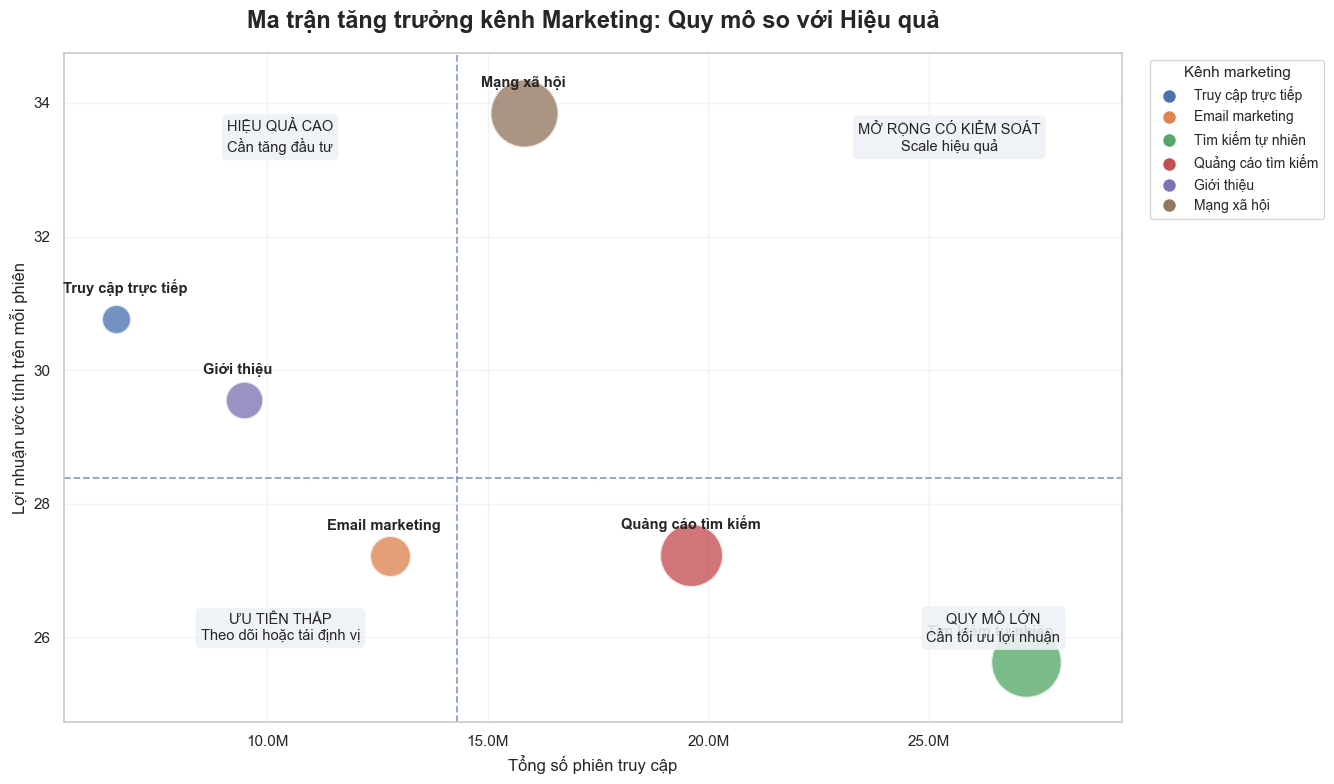

,traffic_source,traffic_source_vi,sessions,orders,revenue,gross_profit,conversion_proxy,revenue_per_session,profit_per_session
5,social_media,Mạng xã hội,"15,816,226","123,261","3,141,422,009","4,172,081",1.040%,259.58,33.85
0,direct,Truy cập trực tiếp,"6,571,549","42,891","1,100,009,291","1,319,274",0.902%,226.61,30.76
4,referral,Giới thiệu,"9,476,845","59,052","1,513,127,797","1,744,952",0.884%,218.78,29.55
3,paid_search,Quảng cáo tìm kiếm,"19,598,271","134,668","3,441,723,469","3,666,350",0.821%,204.39,27.23
1,email_campaign,Email marketing,"12,792,670","71,524","1,834,472,984","1,946,610",0.791%,196.67,27.22
2,organic_search,Tìm kiếm tự nhiên,"27,196,976","172,474","4,387,682,612","4,420,094",0.739%,185.38,25.63


In [66]:
from matplotlib.lines import Line2D
growth_matrix = funnel_summary.merge(
    channel_summary[["order_source", "gross_profit", "aov"]],
    left_on="traffic_source",
    right_on="order_source",
    how="left"
)

growth_matrix["gross_profit"] = (
    growth_matrix["orders"] * growth_matrix["profit_per_session"]
)

x_median = growth_matrix["sessions"].median()
y_median = growth_matrix["profit_per_session"].median()

source_labels = {
    "organic_search": "Tìm kiếm tự nhiên",
    "paid_search": "Quảng cáo tìm kiếm",
    "social_media": "Mạng xã hội",
    "email_campaign": "Email marketing",
    "referral": "Giới thiệu",
    "direct": "Truy cập trực tiếp"
}

growth_matrix["traffic_source_vi"] = growth_matrix["traffic_source"].map(source_labels)

plt.figure(figsize=(13.5, 8))
ax = plt.gca()

# Vẽ từng điểm để kiểm soát legend, size và label tốt hơn
palette = sns.color_palette("deep", n_colors=growth_matrix["traffic_source_vi"].nunique())
color_map = dict(zip(growth_matrix["traffic_source_vi"], palette))

# Scale bubble size
min_size, max_size = 450, 2600
gp_min = growth_matrix["gross_profit"].min()
gp_max = growth_matrix["gross_profit"].max()

growth_matrix["bubble_size"] = (
    min_size
    + (growth_matrix["gross_profit"] - gp_min) / (gp_max - gp_min)
    * (max_size - min_size)
)

for _, row in growth_matrix.iterrows():
    ax.scatter(
        row["sessions"],
        row["profit_per_session"],
        s=row["bubble_size"],
        color=color_map[row["traffic_source_vi"]],
        alpha=0.78,
        edgecolor="white",
        linewidth=1.8,
        label=row["traffic_source_vi"]
    )

# Đường chia quadrant
ax.axvline(x_median, linestyle="--", linewidth=1.3, alpha=0.65)
ax.axhline(y_median, linestyle="--", linewidth=1.3, alpha=0.65)

# Offset nhãn thủ công để tránh bị đè
label_offsets = {
    "organic_search": (-0.8e6, 0.35),
    "paid_search": (0.0, 0.35),
    "social_media": (0.0, 0.35),
    "email_campaign": (-0.15e6, 0.35),
    "referral": (-0.15e6, 0.35),
    "direct": (0.2e6, 0.35),
}

for _, row in growth_matrix.iterrows():
    dx, dy = label_offsets.get(row["traffic_source"], (0, 0.3))
    ax.text(
        row["sessions"] + dx,
        row["profit_per_session"] + dy,
        row["traffic_source_vi"],
        fontsize=10.5,
        fontweight="bold",
        ha="center",
        va="bottom"
    )

# Chú thích quadrant đặt xa điểm hơn
ax.text(
    x_median * 0.72,
    y_median + 5.1,
    "HIỆU QUẢ CAO\nCần tăng đầu tư",
    fontsize=10.5,
    ha="center",
    va="center",
    bbox=dict(boxstyle="round,pad=0.35", facecolor="#EEF2F7", edgecolor="none", alpha=0.9)
)

ax.text(
    x_median * 1.78,
    y_median + 5.1,
    "MỞ RỘNG CÓ KIỂM SOÁT\nScale hiệu quả",
    fontsize=10.5,
    ha="center",
    va="center",
    bbox=dict(boxstyle="round,pad=0.35", facecolor="#EEF2F7", edgecolor="none", alpha=0.9)
)

ax.text(
    x_median * 0.72,
    y_median - 2.25,
    "ƯU TIÊN THẤP\nTheo dõi hoặc tái định vị",
    fontsize=10.5,
    ha="center",
    va="center",
    bbox=dict(boxstyle="round,pad=0.35", facecolor="#EEF2F7", edgecolor="none", alpha=0.9)
)

ax.text(
    x_median * 1.85,
    y_median - 2.25,
    "QUY MÔ LỚN\nCần tối ưu lợi nhuận",
    fontsize=10.5,
    ha="center",
    va="center",
    bbox=dict(boxstyle="round,pad=0.35", facecolor="#EEF2F7", edgecolor="none", alpha=0.9)
)

ax.set_title(
    "Ma trận tăng trưởng kênh Marketing: Quy mô so với Hiệu quả",
    fontsize=17,
    fontweight="bold",
    pad=18
)

ax.set_xlabel("Tổng số phiên truy cập", fontsize=12)
ax.set_ylabel("Lợi nhuận ước tính trên mỗi phiên", fontsize=12)

ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{x/1_000_000:.1f}M")
)

# Giới hạn trục để nhãn không bị sát mép
ax.set_xlim(growth_matrix["sessions"].min() * 0.82, growth_matrix["sessions"].max() * 1.08)
ax.set_ylim(growth_matrix["profit_per_session"].min() - 0.9, growth_matrix["profit_per_session"].max() + 0.9)

# Legend chỉ giữ kênh, không hiện gross_profit size
legend_elements = [
    Line2D(
        [0], [0],
        marker="o",
        color="w",
        label=label,
        markerfacecolor=color_map[label],
        markeredgecolor="white",
        markersize=10
    )
    for label in color_map.keys()
]

ax.legend(
    handles=legend_elements,
    title="Kênh marketing",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=True,
    fontsize=10,
    title_fontsize=11
)

ax.grid(True, alpha=0.22)
plt.tight_layout()
plt.show()

display(growth_matrix[[
    "traffic_source", "traffic_source_vi", "sessions", "orders", "revenue", "gross_profit",
    "conversion_proxy", "revenue_per_session", "profit_per_session"
]].sort_values("profit_per_session", ascending=False).style.format({
    "sessions": "{:,.0f}",
    "orders": "{:,.0f}",
    "revenue": "{:,.0f}",
    "gross_profit": "{:,.0f}",
    "conversion_proxy": "{:.3%}",
    "revenue_per_session": "{:,.2f}",
    "profit_per_session": "{:,.2f}",
}))

##### **Analysis 8 — Prescriptive insight**

Growth matrix chia kênh thành 4 nhóm:

1. **High scale + high efficiency**  
   → Ưu tiên đầu tư mạnh, vì vừa có volume vừa có hiệu quả.

2. **High scale + low efficiency**  
   → Không cắt ngay, nhưng cần tối ưu landing page, targeting, creative, promo, và conversion.

3. **Low scale + high efficiency**  
   → Kênh tiềm năng để thử tăng ngân sách, mở rộng audience, hoặc dùng remarketing.

4. **Low scale + low efficiency**  
   → Chỉ giữ ở mức test nhỏ, không nên là trọng tâm ngân sách.

**Business implication:**  
Đây là biểu đồ nên đặt gần cuối report vì nó chuyển phân tích thành quyết định quản trị.

### **PART B — Tổng hợp insight**

#### 1. Descriptive (Thực trạng - Chuyện gì đã xảy ra?)

Trong giai đoạn quan sát, tăng trưởng đơn hàng và doanh thu chủ yếu đến từ các kênh `organic_search`, `paid_search` và `social_media`. `organic_search` là kênh đóng góp lớn nhất về số đơn, doanh thu và gross profit ước tính. Điều này cho thấy nền tảng tăng trưởng của doanh nghiệp phụ thuộc mạnh vào khả năng khách hàng tự tìm thấy sản phẩm qua tìm kiếm tự nhiên.

Tuy nhiên, khi so sánh AOV giữa các kênh, mức chênh lệch không quá lớn. Vì vậy khác biệt doanh thu giữa các kênh chủ yếu đến từ số lượng đơn hàng, không phải do một kênh tạo ra đơn hàng có giá trị vượt trội. Đây là dấu hiệu rằng bài toán marketing hiện tại là bài toán **scale traffic và conversion**, hơn là chỉ tăng basket size.

#### 2. Diagnostic (Chẩn đoán - Lí do)

Khi nối dữ liệu `web_traffic` với `orders` theo tháng và nguồn traffic/order source, ta thấy kênh có nhiều traffic nhất không nhất thiết là kênh có hiệu quả chuyển đổi tốt nhất. `organic_search` có quy mô lớn nhất, nhưng các kênh nhỏ hơn có thể đạt conversion proxy hoặc revenue/session tốt hơn. Điều này cho thấy một phần traffic lớn có thể chưa được khai thác tối ưu.

Phân tích engagement cho thấy nên kết hợp nhiều chỉ số như bounce rate, session duration, page views/session và conversion proxy. Bounce rate trong dữ liệu khá thấp và không khác biệt mạnh giữa các kênh, nên nếu chỉ dùng bounce rate sẽ khó giải thích hiệu quả kinh doanh. Các chỉ số gần với doanh thu hơn như revenue/session và profit/session phản ánh tốt hơn chất lượng traffic.

Khuyến mãi là một yếu tố quan trọng khác. Dòng sản phẩm có promo chiếm tỷ trọng đáng kể, nhưng average line revenue và gross profit ước tính của nhóm promo thấp hơn nhóm không promo. Điều này gợi ý rằng promo đang giúp kích hoạt volume nhưng cũng có rủi ro làm mỏng margin. Vì vậy, promo nên được dùng có chọn lọc thay vì áp dụng đại trà.

Cuối cùng, kênh marketing cũng khác nhau về chất lượng hậu mua. Các chỉ số rating, bad review rate, return rate và refund/revenue cho thấy không phải mọi đơn hàng đều có giá trị như nhau. Một kênh tạo nhiều đơn nhưng return/review xấu có thể làm giảm tăng trưởng bền vững.

#### 3. Predictive — What is likely to happen?

Xu hướng theo tháng cho thấy orders và revenue có pattern tăng trưởng dài hạn, đồng thời tồn tại yếu tố mùa vụ. Heatmap theo tháng-năm giúp xác định các giai đoạn cao điểm và thấp điểm để lập kế hoạch campaign.

Phân tích YoY growth theo channel giúp nhận diện kênh đang tăng tốc ở cuối giai đoạn dữ liệu. Kênh có base nhỏ nhưng YoY growth cao có thể là growth opportunity, trong khi kênh lớn nhưng growth chậm hơn có thể đã bước vào giai đoạn trưởng thành và cần tối ưu efficiency.

Phân tích lag giữa sessions tháng hiện tại và orders tháng sau cung cấp một cách đơn giản để đánh giá traffic như một leading indicator. Nếu một nguồn traffic có tương quan dương với orders tháng sau, doanh nghiệp có thể dùng sự tăng/giảm traffic làm tín hiệu sớm cho demand planning, inventory và logistics.

#### 4. Prescriptive (Khuyến nghị - Cần hành động gì?)

##### Recommendation 1 — Bảo vệ và tối ưu Organic Search
`organic_search` là kênh nền tảng vì tạo volume và revenue lớn nhất. Doanh nghiệp nên tiếp tục đầu tư SEO, content, product landing pages và technical site performance. Tuy nhiên, vì organic đã lớn, mục tiêu không chỉ là tăng traffic mà còn phải cải thiện conversion và revenue/session.

##### Recommendation 2 — Scale có kiểm soát với Paid Search và Social Media
`paid_search` và `social_media` là các kênh phù hợp để mở rộng tăng trưởng, nhưng cần quản trị theo profit/session thay vì chỉ sessions hoặc orders. Ngân sách nên được phân bổ theo campaign/category có conversion và margin tốt nhất.

##### Recommendation 3 — Tái thiết kế Promotion Strategy
Khuyến mãi không nên chạy đại trà. Nên ưu tiên promo cho:
- tháng thấp điểm,
- category tồn kho cao,
- kênh traffic cao nhưng conversion thấp,
- khách hàng mới cần kích hoạt đơn đầu tiên.

Với các kênh đã có conversion tốt, nên test giảm discount hoặc dùng bundle/free shipping thay vì giảm giá trực tiếp để bảo vệ margin.

##### Recommendation 4 — Dùng Customer Experience làm bộ lọc tăng trưởng
Kênh có rating cao và return rate thấp nên được ưu tiên cho retention, email remarketing và lookalike audience. Kênh có return/bad review cao cần kiểm tra lại targeting, product expectation, size guide, mô tả sản phẩm và logistics.

##### Recommendation 5 — Lập Campaign Calendar theo mùa vụ
Heatmap mùa vụ nên được dùng để lập lịch campaign. Trước tháng cao điểm, doanh nghiệp cần chuẩn bị:
- inventory,
- logistics capacity,
- ngân sách media,
- landing page,
- email/social remarketing.

Trong tháng thấp điểm, chỉ nên dùng promo có kiểm soát để kích cầu mà không phá margin.